In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import statsmodels.api as sm
from scipy.interpolate import interp1d
from tqdm import tqdm
# add project root (parent of figures) to module search path
import sys, os
sys.path.insert(0, os.path.abspath('/home/reilly/ai_scientist_project'))
import utils

cpu
[CpuDevice(id=0)]


In [2]:
# import os, numpy as np, zipfile
# from PIL import Image, ImageSequence
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D  # noqa

# # Read files directly from the specified folder
# extract_dir = "/home/reilly/Downloads/2025-07-03"

# # Collect images
# image_exts = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}
# paths = []
# for root, _, files in os.walk(extract_dir):
#     for f in sorted(files):
#         if os.path.splitext(f)[1].lower() in image_exts:
#             paths.append(os.path.join(root, f))

# if not paths:
#     raise RuntimeError("No images found")

# # Load stack (handles multi-page tiff or multiple separate files)
# stack = []
# if len(paths)==1 and os.path.splitext(paths[0])[1].lower() in {".tif",".tiff"}:
#     im = Image.open(paths[0])
#     for frame in ImageSequence.Iterator(im):
#         arr = np.array(frame.convert("L"), dtype=np.float32)/255.0
#         stack.append(arr)
# else:
#     for p in paths:
#         arr = np.array(Image.open(p).convert("L"), dtype=np.float32)/255.0
#         stack.append(arr)

# # --- Processing ---
# # Crop 50 px border
# cropped = [img[50:-50, 50:-50] for img in stack]

# # Downsample
# downsample_factor = 2
# cropped = [img[::downsample_factor, ::downsample_factor] for img in cropped]

# # ✅ Percentile contrast normalization per plane
# normalized = []
# for img in cropped:
#     vmin = np.percentile(img, 2)    # dark percentile
#     vmax = np.percentile(img, 98)   # bright percentile
#     norm = np.clip((img - vmin) / (vmax - vmin + 1e-6), 0, 1)
#     normalized.append(norm)

# processed = normalized

# # Ensure consistent size
# H, W = processed[0].shape

# # Prepare grid
# y = np.linspace(0, H, H)
# x = np.linspace(0, W, W)
# X, Y = np.meshgrid(x, y)

# spacing = 100   # your chosen z-step

# fig = plt.figure(figsize=(7,7))
# ax = fig.add_subplot(111, projection='3d')

# for i, img in enumerate(processed):
#     img_rgb = np.stack([img, img, img, np.full_like(img, 0.95)], axis=-1)
#     Z = np.full_like(X, i*spacing)
#     ax.plot_surface(X, Y, Z, rstride=3, cstride=3,
#                     facecolors=img_rgb, shade=False, linewidth=0)

# # View settings
# ax.set_xlim(0, W)
# ax.set_ylim(0, H)
# ax.set_zlim(spacing * (len(processed)-1), 0)  # plane 0 on top
# ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
# ax.view_init(elev=25, azim=-60)
# ax.set_axis_off()

# plt.tight_layout()
# plt.show()
# # save as vector graphic
# plt.savefig('/home/reilly/ai_scientist_project/figures/3d_stack_visualization.svg', format='svg', dpi=300, bbox_inches='tight')


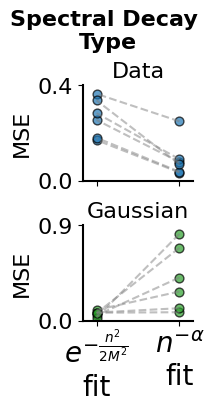

In [3]:
plot_mean = False
plot_ai = False
mse1_gaussian = [0.398, 0.078, 0.269, 0.115, 0.800, 0.672]
mse2_gaussian = [0.049, 0.073, 0.099, 0.075, 0.028, 0.069]
mse1_data     = [0.227, 0.031, 0.071, 0.034, 0.082, 0.062]
mse2_data     = [0.332, 0.155, 0.232, 0.164, 0.258, 0.307]
mse1_AI       = [0.007, 0.018, 0.021, 0.019, 0.043, 0.048]
mse2_AI       = [0.082, 0.080, 0.118, 0.091, 0.188, 0.180]
x_min, x_max = 0.75, 2.25
scale_factor = 2.0
fig, axes = plt.subplots(2 + int(plot_ai), 1, figsize=(1 * scale_factor, 2 * scale_factor), constrained_layout=True)

# Define the data for Gaussian, Data
mse1 = [mse1_data, mse1_gaussian]
mse2 = [mse2_data, mse2_gaussian]
titles = ['Data', 'Gaussian']
colors = ['tab:blue', 'tab:green']
if plot_ai:
    mse1.append(mse1_AI)
    mse2.append(mse2_AI)
    titles.append('AI')
    colors.append('tab:red')

for i, ax in enumerate(axes):
    x_loglog = np.ones(6) * x_max
    y_loglog = np.array(mse1[i])
    x_loglinear = np.ones(6) * x_min
    y_loglinear = np.array(mse2[i])
    y_loglog_mean = y_loglog.mean()
    y_loglinear_mean = y_loglinear.mean()

    ax.scatter(x_loglog, y_loglog, s=20 * scale_factor, alpha=0.7, c=colors[i], edgecolors='k')
    ax.scatter(x_loglinear, y_loglinear, s=20 * scale_factor, alpha=0.7, c=colors[i], edgecolors='k')
    if plot_mean:
        ax.scatter([2], [y_loglog_mean], s=30 * scale_factor, c=colors[i], marker='^', edgecolors='k', alpha=0.9,
                label='Mean', zorder=5)
        ax.scatter([1], [y_loglinear_mean], s=30 * scale_factor, c=colors[i], marker='^', edgecolors='k', alpha=0.9, zorder=5)
        ax.plot([2, 1], [y_loglog_mean, y_loglinear_mean], color='black', linestyle='--', alpha=0.8)
        ax.legend(fontsize=12, loc='upper right')

    # Add grey lines joining pairs
    for j in range(len(y_loglog)):
        ax.plot([x_loglog[j], x_loglinear[j]], [y_loglog[j], y_loglinear[j]], color='gray', linestyle='--', alpha=0.5)

    ax.set_xticks([x_max, x_min])
    if i == len(axes) - 1:
        ax.set_xticklabels([r'$n^{-\alpha}$' + '\nfit', r'$e^{-\frac{n^2}{2M^2}}$' + '\nfit'], fontsize=10 * scale_factor)
    else:
        ax.set_xticklabels([], fontsize=12 * scale_factor)
    ax.set_ylabel('MSE', fontsize=8 * scale_factor)
    ax.set_xlim(0.5, 2.5)
    ax.set_title(titles[i], fontsize=8 * scale_factor)
    # add y tick at 0 and max value
    y_min = 0
    y_max = max(max(mse1[i]), max(mse2[i])) * 1.1
    ax.set_ylim(y_min, y_max)
    ax.set_yticks([0, y_max])
    ax.set_yticklabels([f'{y_min:.1f}', f'{y_max:.1f}'], fontsize=8 * scale_factor)
    # turn off top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # make bottom and left spines thicker
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)

# plt.tight_layout()
plt.suptitle('Spectral Decay \nType', fontsize=8 * scale_factor, weight='bold')
plt.show()


In [4]:
# define funcs up here

def vanilla_cvpca(R1, R2):
    # R1: n_cells x n_stim
    # R2: n_cells x n_stim
    # return evals: n_stim
    n_cells, n_angles = R1.shape
    # # normalize each cell to have the same amplitude
    # R1 = R1 / np.mean(R1**2, axis = 1, keepdims=True)**0.5
    # R2 = R2 / np.mean(R2**2, axis = 1, keepdims=True)**0.5
    # center each stimulus to have zero mean
    R1z = (R1 - R1.mean(axis = 0, keepdims=True)) / (R1.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    R2z = (R2 - R2.mean(axis = 0, keepdims=True)) / (R2.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    C11 = R1z.T @ R1z / n_cells # n_stim x n_stim
    evals, evecs = np.linalg.eigh(C11)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    # project onto C12
    C12 = R1z.T @ R2z / n_cells # n_stim x n_stim
    evals = np.diag(evecs.T @ C12 @ evecs)
    return evals

def three_rep_cvpca(R1, R2, R3):
    # R1: n_cells x n_stim
    # R2: n_cells x n_stim
    # R3: n_cells x n_stim
    # return evals: n_stim
    n_cells, n_angles = R1.shape
    # # normalize each cell to have the same amplitude
    # R1 = R1 / np.mean(R1**2, axis = 1, keepdims=True)**0.5
    # R2 = R2 / np.mean(R2**2, axis = 1, keepdims=True)**0.5
    # R3 = R3 / np.mean(R3**2, axis = 1, keepdims=True)**0.5
    # center each stimulus to have zero mean
    R1z = (R1 - R1.mean(axis = 0, keepdims=True)) / (R1.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    # R1z = R1 - R1.mean(axis = 0, keepdims=True)
    R2z = (R2 - R2.mean(axis = 0, keepdims=True)) / (R2.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    # R2z = R2 - R2.mean(axis = 0, keepdims=True)
    R3z = (R3 - R3.mean(axis = 0, keepdims=True)) / (R3.std(axis = 0, keepdims=True, ddof=0) + 1e-10)
    # R3z = R3 - R3.mean(axis = 0, keepdims=True)
    C11 = R1z.T @ R1z / n_cells # n_stim x n_stim
    evals, evecs = np.linalg.eigh(C11)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]
    # project onto C23 
    C23 = R2z.T @ R3z / n_cells # n_stim x n_stim
    evals = np.diag(evecs.T @ C23 @ evecs)
    return evals
    
def sym_cvpca(R, R_smooth):
    counter = 0
    n_repeats, n_cells, n_angles = R.shape
    evals_sym = np.zeros(n_angles)
    for i in range(n_repeats):
        A = R_smooth[i]
        # loop over all distinct B, C pairs not equal to A
        alt_indices = [j for j in range(n_repeats) if j != i]
        for j, idx1 in enumerate(alt_indices):
            for k, idx2 in enumerate(alt_indices):
                if j >= k:
                    continue
                B = R[idx1]
                C = R[idx2]
                evals_temp = three_rep_cvpca(A, B, C)
                evals_sym += evals_temp
                counter += 1
    evals_sym /= counter
    return np.array(evals_sym, dtype=np.float64)

def fit_lowess(R, theta, frac=0.05):
    """
    Fit LOWESS smoothed responses for all cells with a fixed bandwidth.

    Parameters
    ----------
    R : (n_cells, n_trials)
        Response matrix.
    theta : (n_trials,)
        Angles (radians).
    frac : float (0,1)
        Smoothing parameter for LOWESS.
    Returns
    -------
    R_smooth : (n_cells, n_trials)
        Smoothed predictions for each cell.
    """
    n_cells, _ = R.shape
    x_range = theta.max() - theta.min()
    R_smooth = np.zeros_like(R)
    order = np.argsort(theta)
    theta_sorted = theta[order]

    for c in tqdm(range(n_cells), desc="Fitting all cells"):
        R_sorted = R[c, order]
        mean_est = sm.nonparametric.lowess(R_sorted, theta_sorted, frac=frac, it=0, delta=0.01 * x_range,
                                           return_sorted=True)
        R_smooth[c] = np.interp(theta_sorted, mean_est[:, 0], mean_est[:, 1])

    return R_smooth

def gaussian_smooth(R, theta, bandwidth_rad=np.pi/8):
    """
    Smooth responses for all cells using a Gaussian kernel.

    Parameters
    ----------
    R : (n_cells, n_trials)
        Response matrix.
    theta : (n_trials,)
        Angles (radians).
    bandwidth_rad : float
        Standard deviation of Gaussian kernel in radians.

    Returns
    -------
    R_smooth : (n_cells, n_trials)
        Smoothed predictions for each cell.
    """
    # Precompute Gaussian kernel
    circ_dist = lambda x, y: np.minimum(np.abs(x - y), 2 * np.pi - np.abs(x - y))
    angle_diffs = circ_dist(theta[None, :], theta[:, None])  # (n_trials, n_trials)
    kernel = np.exp(-0.5 * (angle_diffs / bandwidth_rad) ** 2)
    kernel /= kernel.sum(axis=1, keepdims=True)  # normalize

    # Perform smoothing using matrix multiplication
    R_smooth = kernel @ R.T
    R_smooth = R_smooth.T  # Transpose back to original shape (n_cells, n_trials)

    return R_smooth


def smooth_curve(points, upsample=4, kind='cubic'):
    """
    points: (n_orientations,3)
    upsample: how many times more samples to produce
    """
    n = points.shape[0]
    # parameter: equally spaced samples 0..1
    t = np.linspace(0, 1, n, endpoint=False)
    t_new = np.linspace(0, 1, n*upsample, endpoint=False)

    smooth = np.empty((len(t_new), points.shape[1]))
    for dim in range(points.shape[1]):
        f = interp1d(t, points[:, dim],
                     kind=kind,
                     fill_value='extrapolate',
                     assume_sorted=True)
        smooth[:, dim] = f(t_new)

    # close loop
    smooth = np.vstack([smooth, smooth[0]])
    return smooth

# PLOTTING FUNCTIONS

from matplotlib.patches import Rectangle

def plot_evals_with_mse_table(
    evals_list: list[np.ndarray], 
    labels: list[str], 
    colors: list[str] = None,
    markersize: int = 4,
    fit_line: list[bool] = [True], 
    fit_type: list[str] = ['loglog'],  # 'loglog' (α) or 'quadratic' (β)
    plot_negative: list[bool] = [True],
    legend_loc: str = 'center right',
    fontsize: int = 14,
    alpha: float = 0.7,
    fit_range: tuple[int, int] = (10, 100), 
    title: str = 'cvPCA Eigenvalues', 
    x_lim: tuple[float, float] = None, 
    y_lim: tuple[float, float] = None,
    plot_table: bool = True,
    scale_factor: float = 1.0,
    rectangle_coords: tuple[float, float, float, float] = (0.15, 0.05, 0.45, 0.22)
):
    """Plots eigenvalue spectra with log–log and quadratic fits,
    showing an MSE comparison table with scaled dots and best-fit highlighting."""

    # Normalize eigenvalues
    evals_list = [evals / np.nansum(evals) for evals in evals_list]
    n_sets = len(evals_list)

    # Expand arguments to lists
    if isinstance(fit_line, bool): fit_line = [fit_line] * n_sets
    if isinstance(plot_negative, bool): plot_negative = [plot_negative] * n_sets
    if isinstance(fit_type, str): fit_type = [fit_type] * n_sets
    if colors is None: colors = plt.cm.tab10(np.arange(n_sets))

    fontsize = fontsize * scale_factor
    markersize = int(markersize * scale_factor)
    fig, ax = plt.subplots(figsize=(3 * scale_factor, 2.0 * scale_factor))
    params = np.zeros(n_sets)

    def sci_notation(num: float, precision: int = 2) -> str:
        if num == 0: return "0"
        exponent = int(np.floor(np.log10(abs(num))))
        mantissa = num / 10**exponent
        if exponent == 0:
            return f"{mantissa:.{precision}f}"
        else:
            return fr"{mantissa:.{precision}f} \times 10^{{{exponent}}}"

    mse_loglog, mse_quad = [], []

    # --- Fit models and compute MSE ---
    for i, (evals, label) in enumerate(zip(evals_list, labels)):
        x_vals = np.arange(len(evals))
        mask = (evals > 0) & (x_vals >= fit_range[0]) & (x_vals <= fit_range[1])
        if not np.any(mask):
            mse_loglog.append(np.nan)
            mse_quad.append(np.nan)
            continue

        # log–log fit
        coeff_loglog = np.polyfit(np.log(x_vals[mask]), np.log(evals[mask]), 1)
        pred_loglog = np.exp(np.polyval(coeff_loglog, np.log(x_vals[mask])))
        mse_a = np.mean((np.log(evals[mask]) - np.log(pred_loglog))**2)
        mse_loglog.append(mse_a)

        # quadratic fit
        coeff_quad = np.polyfit(x_vals[mask]**2, np.log(evals[mask]), 1)
        pred_quad = np.exp(np.polyval(coeff_quad, x_vals[mask]**2))
        mse_b = np.mean((np.log(evals[mask]) - np.log(pred_quad))**2)
        mse_quad.append(mse_b)

        # Plot the primary chosen fit
        if fit_type[i] == 'loglog':
            params[i] = coeff_loglog[0]
            if fit_line[i]:
                ax.plot(x_vals, np.exp(np.polyval(coeff_loglog, np.log(x_vals))),
                        '--', color=colors[i], alpha=0.7)
        else:
            params[i] = np.sqrt(1/(2 * abs(coeff_quad[0])))
            if fit_line[i]:
                ax.plot(x_vals, np.exp(np.polyval(coeff_quad, x_vals**2)),
                        '-.', color=colors[i], alpha=0.7)

    # --- Plot eigenvalue data ---
    for i, (evals, label) in enumerate(zip(evals_list, labels)):
        symbol = r'\alpha' if fit_type[i] == 'loglog' else r'M'
        formatted_val = sci_notation(abs(params[i]))
        lbl = fr"{label}: ${symbol} = {formatted_val}$" if fit_line[i] else label
        ax.plot(evals, 'o', ms=markersize, alpha=alpha,
                label=lbl, color=colors[i],
                markeredgecolor='black', markeredgewidth=0.5)

    # --- Vertical lines at fit range ---
    if fit_range is not None:
        ax.axvline(fit_range[0], color='gray', linestyle='--', alpha=0.5)
        ax.axvline(fit_range[1], color='gray', linestyle='--', alpha=0.5)

    # --- Axes formatting ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    if x_lim: ax.set_xlim(x_lim)
    if y_lim: ax.set_ylim(y_lim)
    ax.set_xlabel('Component', fontsize=fontsize + 2 * scale_factor)
    ax.set_ylabel('Variance Explained', fontsize=fontsize + 2 * scale_factor)
    ax.set_xticks([1, 10, 50], labels=['1', '10', '50'], fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize + 2 * scale_factor)  
    # ax.grid(True, which='both', linestyle='--', alpha=0.5)
    # turn off top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # make bottom and left spines thicker
    ax.spines['bottom'].set_linewidth(1 * scale_factor)
    ax.spines['left'].set_linewidth(1 * scale_factor)
    # set tick label size
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    # --- Plot negative eigenvalues if requested ---
    for i, (evals, label) in enumerate(zip(evals_list, labels)):
        if plot_negative[i]:
            y_mask = evals <= 0
            if np.any(y_mask):
                x_vals = np.arange(len(evals))
                # choose a small
                y_min = ax.get_ylim()[0]
                ax.scatter(
                    x_vals[y_mask],
                    np.full(np.sum(y_mask), y_min * 1.1),
                    marker='x', s=markersize*20,
                    color=colors[i],
                    alpha=0.7,
                    label=f'{label}: -ve values'
                )
    # put the legend in the very bottom left corner
    ax.legend(loc='lower left', fontsize=fontsize, frameon=True, bbox_to_anchor=(-0.0, -0.0))
    
    if not plot_table:
        plt.tight_layout()
        plt.show()
        return
    # --- Create MSE Table ---
    col_labels = [r'$V_n \propto n^{-\alpha}$', r'$V_n \propto e^{-n^2/2M^2}$']
    cell_text = [[f"{mse_loglog[i]:.3f}", f"{mse_quad[i]:.3f}"] for i in range(n_sets)]

    # Background rectangle behind table
    rect = Rectangle(rectangle_coords[:2], rectangle_coords[2], rectangle_coords[3],
                     transform=ax.transAxes, color='white', alpha=1, zorder=2,
                     ec='black', lw=0.5)
    ax.add_patch(rect)

    # Title for table
    ax.text(rectangle_coords[0] + rectangle_coords[2] / 2,
            rectangle_coords[1] + rectangle_coords[3],
            'MSE for Eigenvalue Decay Models',
            transform=ax.transAxes, fontsize=fontsize,
            ha='center', va='bottom', fontweight='bold')

    # Draw table
    table = ax.table(
        cellText=cell_text,
        rowLabels=labels,
        colLabels=col_labels,
        loc='lower left',
        bbox=rectangle_coords,
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize - 2)
    table.scale(1.0, 1.15)
    table.set_zorder(3)

    # --- Style table cells ---
    all_mses = np.array([mse_loglog, mse_quad]).T
    max_mse = np.nanmax(all_mses)
    min_mse = np.nanmin(all_mses)

    for i, label in enumerate(labels):
        row_mses = [mse_loglog[i], mse_quad[i]]
        best_idx = np.nanargmin(row_mses)

        for j in range(2):
            cell = table[(i + 1, j)]
            cell.get_text().set_color(colors[i])

            # Scale dots based on MSE (smaller MSE → larger dot)
            mse_value = row_mses[j]
            cell.get_text().set_text(f"{mse_value:.3f}")
            cell.get_text().set_fontweight('normal')

            # Highlight best-fit entry
            if j == best_idx:
                cell.set_edgecolor('black')
                cell.set_linewidth(3)
                cell.get_text().set_fontweight('bold')
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------
# ----------  Styling helpers (same as your code)  ----------
# -----------------------------------------------------------
def add_z_band_on_walls(ax, zmin, zmax, color, alpha=0.1, ls='--'):
    """Shade z-extent on back walls (xz & yz planes) with dashed outlines."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    walls = [
        [(xmin, ymin, zmin), (xmin, ymin, zmax),
         (xmin, ymax, zmax), (xmin, ymax, zmin)],          # yz wall
        [(xmin, ymax, zmin), (xmax, ymax, zmin),
         (xmax, ymax, zmax), (xmin, ymax, zmax)]           # xz wall
    ]
    ax.add_collection3d(
        Poly3DCollection(walls, facecolors=color, alpha=alpha, linewidths=0)
    )

    # dashed edges
    ax.plot([xmin, xmin], [ymin, ymax], [zmin, zmin], color=color, ls=ls, alpha=3*alpha)
    ax.plot([xmin, xmin], [ymin, ymax], [zmax, zmax], color=color, ls=ls, alpha=3*alpha)
    ax.plot([xmin, xmax], [ymax, ymax], [zmin, zmin], color=color, ls=ls, alpha=3*alpha)
    ax.plot([xmin, xmax], [ymax, ymax], [zmax, zmax], color=color, ls=ls, alpha=3*alpha)

def draw_axes_cross(ax, axis_alpha=0.6):
    """Black reference axes meeting at lower-front corner."""
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    zmin, zmax = ax.get_zlim()
    x0, y0, z0 = xmin, ymax, zmin
    d = 2
    ax.plot([x0, x0], [y0, y0], [zmin, zmax], color='k', alpha=axis_alpha,
            lw=3, linestyle=(0, (1, d)))  # dotted z-axis
    ax.plot([xmin, xmax], [y0, y0], [z0, z0], color='k', alpha=axis_alpha, lw=1.5)
    ax.plot([x0, x0], [ymin, ymax], [z0, z0], color='k', alpha=axis_alpha, lw=1.5)

def style_axis(ax, floor_dist=2, zlabel='PC 3', fontsize=16):
    """Remove grid, label axes, fix z-range & view."""
    ax.grid(False)
    ax.set_xlabel('PC 1', labelpad=16, fontsize=fontsize)
    ax.set_ylabel('PC 2', labelpad=16, fontsize=fontsize)
    ax.set_zlabel(zlabel, labelpad=8, fontsize=fontsize)
    ax.set_zlim(-floor_dist, floor_dist)
    ax.view_init(elev=25, azim=-30)

# -----------------------------------------------------------
# ----------  Main reusable plotting function  --------------
# -----------------------------------------------------------
def plot_point_clouds_3d(clouds, *,
                         colors=None,
                         labels=None,
                         floor_dist=2,
                         band_alpha=0.1,
                         axis_alpha=0.55,
                         z_label='z',
                         title='3D Point-Cloud Projections',
                         figsize=(6, 5)):
    """
    Plot any number of 3-D point-cloud curves side-by-side.

    Parameters
    ----------
    clouds : list of (N,3) arrays
        Each array is a 3-D curve/point-cloud.
    colors : list of str
        Matplotlib colors for each cloud (defaults to cycle).
    labels : list of str
        Legends for each subplot.
    floor_dist : float
        Distance below the xy-plane for floor projection.
    """
    n = len(clouds)
    if colors is None:
        colors = plt.cm.tab10.colors
    if labels is None:
        labels = [f'Cloud {i+1}' for i in range(n)]

    fig = plt.figure(figsize=(figsize[0] * n, figsize[1]))
    for i, (pts, c, lab) in enumerate(zip(clouds, colors, labels), start=1):
        ax = fig.add_subplot(1, n, i, projection='3d')

        # plot curve
        ax.plot(*pts.T, color=c, label=lab,
                # marker='o', markersize=3, lw=1, alpha=0.8
                )
        # project curve to "floor"
        ax.plot(pts[:, 0], pts[:, 1],
                -floor_dist * np.ones_like(pts[:, 0]),
                color=c, alpha=0.35, lw=1)

        style_axis(ax, floor_dist=floor_dist, zlabel=z_label)
        ax.autoscale_view()
        ax.set_xlim(*ax.get_xlim())
        ax.set_ylim(*ax.get_ylim())

        add_z_band_on_walls(ax, pts[:, 2].min(), pts[:, 2].max(),
                            c, alpha=band_alpha)
        draw_axes_cross(ax, axis_alpha)
        ax.legend(loc='upper right', fontsize=16)
        # change viewing angle
        # ax.view_init(elev=30, azim=-30)

    plt.subplots_adjust(wspace=0.3, top=0.9, bottom=0.1,
                        left=0.05, right=0.95)
    plt.suptitle(title, fontsize=24, y=0.95)
    plt.tight_layout()
    plt.show()


def plot_point_clouds_3d_nested(
    clouds, *,
    colors=None,
    labels=None,
    floor_dist=2,
    band_alpha=0.1,
    axis_alpha=0.55,
    z_label='z',
    title='3D Point-Cloud Projections',
    figsize=(6, 5)
):
    """
    Plot any number of 3-D point-cloud curves side-by-side.
    Allows multiple curves per subplot while preserving geometry and style.
    """
    n = len(clouds)
    if colors is None:
        colors = plt.cm.tab10.colors
    if labels is None:
        labels = [f'Cloud {i+1}' for i in range(n)]

    fig = plt.figure(figsize=(figsize[0] * n, figsize[1]))

    for i, (item, c_entry, l_entry) in enumerate(zip(clouds, colors, labels), start=1):
        ax = fig.add_subplot(1, n, i, projection='3d')

        # Normalize input to lists
        subclouds = item if isinstance(item, (list, tuple)) else [item]
        sub_colors = c_entry if isinstance(c_entry, (list, tuple)) else [c_entry]
        sub_labels = l_entry if isinstance(l_entry, (list, tuple)) else [l_entry]

        # Cycle colors/labels if needed
        if len(sub_colors) < len(subclouds):
            sub_colors = list(sub_colors) * int(np.ceil(len(subclouds)/len(sub_colors)))
        if len(sub_labels) < len(subclouds):
            sub_labels = [f'{sub_labels[0]}_{j+1}' for j in range(len(subclouds))]

        # --- Plot each sub-cloud ---
        j = 0
        for pts, c, lab in zip(subclouds, sub_colors, sub_labels):
            ax.plot(*pts.T, color=c, lw=2.5, alpha=0.9, label=lab,
                    linestyle='--' if j > 0 else '-')  # first solid, rest dashed
            ax.plot(pts[:, 0], pts[:, 1],
                    -floor_dist * np.ones_like(pts[:, 0]),
                    color=c, alpha=0.35, lw=1)
            j += 1

        # --- Axis styling (same sequence as original) ---
        style_axis(ax, floor_dist=floor_dist, zlabel=z_label, fontsize=24)
        ax.autoscale_view()
        ax.set_xlim(*ax.get_xlim())
        ax.set_ylim(*ax.get_ylim())
        # only have 3 ticks on each axis
        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.yaxis.set_major_locator(plt.MaxNLocator(3))
        ax.zaxis.set_major_locator(plt.MaxNLocator(3))
        # set ticks to have fontsize 24
        ax.tick_params(axis='both', which='major', labelsize=24)
        # add z-band on walls in the first colour, but for the whole z-range
        z_min = min([p[:, 2].min() for p in subclouds])
        z_max = max([p[:, 2].max() for p in subclouds])
        add_z_band_on_walls(ax, z_min, z_max, sub_colors[0], alpha=band_alpha)
        draw_axes_cross(ax, axis_alpha)
        ax.legend(loc='upper right', fontsize=24)

    plt.subplots_adjust(wspace=0.3, top=0.9, bottom=0.1,
                        left=0.05, right=0.95)
    plt.suptitle(title, fontsize=24, y=0.95)
    plt.tight_layout()
    plt.show()


# ---------- unified plotter ----------
def plot_point_clouds_3d_onefig(clouds,
                                colors=None,
                                labels=None,
                                floor_dist=2,
                                band_alpha=0.1,
                                axis_alpha=0.55,
                                title='3D Projections',
                                figsize=(8, 6),
                                z_label='PC 3'):
    """
    Plot all 3-D point-cloud curves in a single 3-D axis.
      clouds: list of (N,3) arrays
    """
    n = len(clouds)
    if colors is None:
        colors = plt.cm.tab10.colors
    if labels is None:
        labels = [f'Cloud {i+1}' for i in range(n)]

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # plot every curve
    for pts, c, lab in zip(clouds, colors, labels):
        ax.plot(*pts.T, color=c, label=lab, lw=1.5, alpha=0.9)
        ax.plot(pts[:, 0], pts[:, 1],
                -floor_dist * np.ones_like(pts[:, 0]),
                color=c, alpha=0.3, lw=1)

    # axis styling
    style_axis(ax, floor_dist=floor_dist, zlabel=z_label)
    ax.autoscale_view()
    # adjust elevation and azimuth
    ax.view_init(elev=25, azim=-30)

    # choose one band just for the overall z-range
    all_z = np.concatenate([p[:, 2] for p in clouds])
    add_z_band_on_walls(ax, all_z.min(), all_z.max(),
                        'gray', alpha=band_alpha)
    draw_axes_cross(ax, axis_alpha)

    ax.legend(loc='upper right', fontsize=11)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [5]:
data_dir = '/home/reilly/Desktop/ai_scientist_paper/cvpca_data/stringer1'
R = np.load(f'{data_dir}/r.npy')
angles = np.load(f'{data_dir}/angles.npy')
pred = np.load(f'{data_dir}/pred.npy')
pred_gauss = np.load(f'{data_dir}/pred_gauss.npy')
params = np.load(f'{data_dir}/params.npy')
R_double = np.load(f'{data_dir}/r_double.npy')
angles_double = np.load(f'{data_dir}/angles_double.npy')
pred_double = np.load(f'{data_dir}/pred_double.npy')
pred_gauss_double = np.load(f'{data_dir}/pred_gauss_double.npy')
params_double = np.load(f'{data_dir}/params_double.npy')
R_mean = R.mean(axis=0)
n_repeats, n_cells, n_angles = R.shape
# get a noise level estimate from the repeated trials
noise_level = np.zeros((n_cells, n_angles))
rad = 3
for theta in range(n_angles):
    # take std across repeats for theta - rad to theta + rad
    indices = np.arange(theta - rad, theta + rad + 1) % n_angles
    recordings = R[:, :, indices]
    noise_level[:, theta] = recordings.std(axis=(0, 2))

# combine every 2 repeats into 1
# R = R.reshape(n_repeats // 2, 2, n_cells, n_angles).mean(axis=1)
# n_repeats = R.shape[0]

# reshape R to have 2*n_repeats repeats by taking the even and odd angles separately
# R_even = R[:, :, 0::2]
# R_odd = R[:, :, 1::2]
# R = np.concatenate([R_even, R_odd], axis=0)
# angles = angles[0::2]
# n_repeats, n_cells, n_angles = R.shape

# R = R[:, :600]
# pred = pred[:600]
# pred_gauss = pred_gauss[:600]
# n_cells = R.shape[1]

print(f"n_repeats: {n_repeats}, n_cells: {n_cells}, n_angles: {n_angles}")
# get average correlation between repeats
corr = np.zeros(n_cells)
for c in range(n_cells):
    R_c = R[:, c, :]
    corr_matrix = np.corrcoef(R_c)
    # take upper triangle without diagonal
    triu_indices = np.triu_indices(n_repeats, k=1)
    corr[c] = np.nanmean(corr_matrix[triu_indices])
# signal_fractions = utils.unbiased_signal_fraction(R)[0]
# good = signal_fractions > 0.9
# R = R[:, good, :]
# pred = pred[good, :]
# pred_gauss = pred_gauss[good, :]
# n_cells = R.shape[1]
# signal_fractions = signal_fractions[good]
# print(f"n_cells after signal fraction cut: {n_cells}")


n_repeats: 6, n_cells: 1604, n_angles: 256


In [6]:
# # noise = np.array([np.random.normal(0, noise_level, size=pred.shape) for _ in range(n_repeats)])
# seed = 43
# rng = np.random.default_rng(seed)
# noise = rng.normal(0, noise_level, size=(n_repeats, n_cells, n_angles))
# pred_noisy = pred[None, :, :] + noise
# cell_no = np.random.randint(0, n_cells)
# plt.plot(angles, R[:, cell_no, :].T, color='gray', alpha=0.3)
# plt.plot(angles, pred_noisy[0, cell_no, :], color='red', label='pred + noise')
# plt.plot(angles, pred[cell_no, :], color='blue', label='pred')
# plt.xlabel('Stimulus angle (rad)')
# plt.ylabel('Response')
# plt.title(f'Cell {cell_no} responses with noisy prediction')
# plt.legend()
# plt.show()

# # call it R_sim
# R_sim = pred_noisy.copy()

In [7]:
# --- Parameters ---
bw_min, bw_max = 0.0, 1.0
tol = 1e-4          # stop when search interval is small
max_iter = 16       # number of binary search iterations

# --- Helper: compute cross-validated MSE across distinct sessions ---
def evaluate_bw(R, bw, mae: bool = True):
    """Smooth all repeats with given bandwidth and compute mean cross-validated MSE.
    if mae=True, return MAE instead of MSE.
    """
    R_smooth_tmp = np.zeros_like(R)

    # Smooth all repeats
    for session in range(n_repeats):
        R_smooth_tmp[session] = gaussian_smooth(R[session], theta=angles, bandwidth_rad=bw)

    # Cross-validated MAE across distinct session pairs
    mae_vals = []
    mse_vals = []
    for c in range(n_cells):
        for i in range(n_repeats):
            for j in range(n_repeats):
                if i == j:
                    continue  # distinct sessions only
                diff = R_smooth_tmp[i, c, :] - R[j, c, :]
                mae_vals.append(np.nanmean(np.abs(diff)))
                mse_vals.append(np.nanmean(diff**2))
    mae_vals = np.array(mae_vals)
    mse_vals = np.array(mse_vals)
    return np.nanmean(mae_vals) if mae else np.nanmean(mse_vals)


# --- Binary search for MAE minimum ---
low, high = bw_min, bw_max
best_frac, best_loss = None, np.inf

for it in range(max_iter):
    mid = (low + high) / 2
    delta = (high - low) / 4  # small perturbation for left/right comparisons

    left_bw = max(bw_min, mid - delta)
    right_bw = min(bw_max, mid + delta)

    loss_left = evaluate_bw(R, left_bw)
    loss_right = evaluate_bw(R, right_bw)
    print(f"Iter {it+1}: left={left_bw:.4f} Loss={loss_left:.6f}, right={right_bw:.4f} Loss={loss_right:.6f}")

    # Move toward side with lower MAE
    if loss_left < loss_right:
        high = mid
        best_bw, best_loss = left_bw, loss_left
    else:
        low = mid
        best_bw, best_loss = right_bw, loss_right

    if abs(high - low) < tol:
        break

print(f"\nBest bw ≈ {best_bw:.4f} (mean cross-val Loss={best_loss:.6f})")


# --- Final smoothing with best bw ---
R_smooth = np.zeros_like(R)
for session in tqdm(range(n_repeats), desc=f"Final smoothing (bw={best_bw:.4f})"):
    R_smooth[session] = gaussian_smooth(R[session], theta=angles, bandwidth_rad=best_bw)


# --- Final cross-validated MAE (for reporting) ---
mae_vals = []
mse_vals = []
for c in range(n_cells):
    for i in range(n_repeats):
        for j in range(n_repeats):
            if i == j:
                continue
            diff = R_smooth[i, c, :] - R[j, c, :]
            mae_vals.append(np.nanmean(np.abs(diff)))
            mse_vals.append(np.nanmean(diff**2))
mae_vals = np.array(mae_vals)
mse_vals = np.array(mse_vals)

print(f"\nFinal cross-validated MAE (best bw): {mae_vals.mean():.6f} ± {mae_vals.std():.6f}")
print(f"Final cross-validated MSE (best bw): {mse_vals.mean():.6f} ± {mse_vals.std():.6f}")
R_smooth_mean = R_smooth.mean(axis=0)


Iter 1: left=0.2500 Loss=0.266179, right=0.7500 Loss=0.418481
Iter 2: left=0.1250 Loss=0.232012, right=0.3750 Loss=0.311332
Iter 3: left=0.0625 Loss=0.227611, right=0.1875 Loss=0.246253
Iter 4: left=0.0312 Loss=0.234938, right=0.0938 Loss=0.228151
Iter 5: left=0.0781 Loss=0.227345, right=0.1094 Loss=0.229753
Iter 6: left=0.0703 Loss=0.227319, right=0.0859 Loss=0.227635
Iter 7: left=0.0664 Loss=0.227421, right=0.0742 Loss=0.227297
Iter 8: left=0.0723 Loss=0.227298, right=0.0762 Loss=0.227312
Iter 9: left=0.0713 Loss=0.227306, right=0.0732 Loss=0.227295
Iter 10: left=0.0728 Loss=0.227296, right=0.0737 Loss=0.227295
Iter 11: left=0.0735 Loss=0.227295, right=0.0740 Loss=0.227296
Iter 12: left=0.0734 Loss=0.227295, right=0.0736 Loss=0.227295
Iter 13: left=0.0733 Loss=0.227295, right=0.0734 Loss=0.227295
Iter 14: left=0.0734 Loss=0.227295, right=0.0735 Loss=0.227295

Best bw ≈ 0.0735 (mean cross-val Loss=0.227295)


Final smoothing (bw=0.0735): 100%|██████████| 6/6 [00:00<00:00, 173.84it/s]



Final cross-validated MAE (best bw): 0.227295 ± 0.056430
Final cross-validated MSE (best bw): 0.240048 ± 0.092294


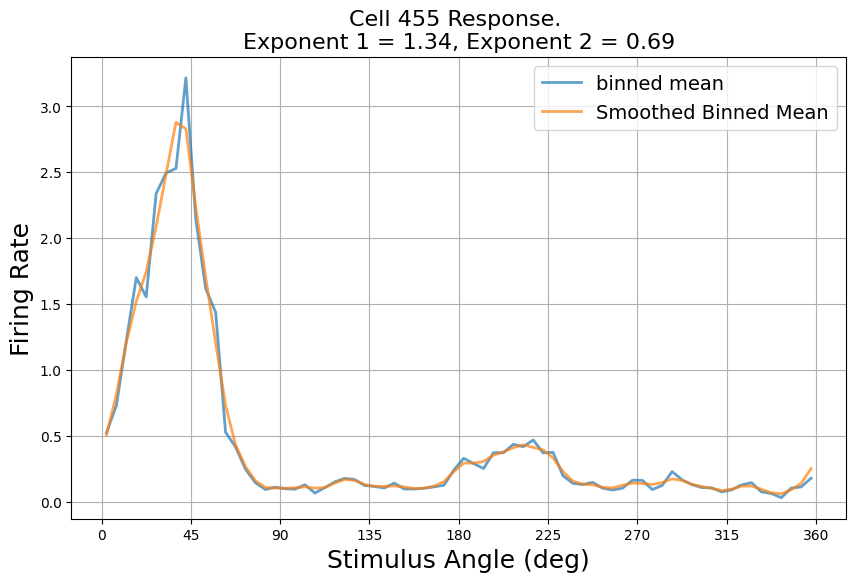

In [8]:
cell_no = np.random.randint(0, n_cells)
# cell_no = 1652
# binned mean calculation
n_bins = 72
bin_edges = np.linspace(0, 2 * np.pi, n_bins + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:])/2
angle_masks = [(angles >= bin_edges[i]) & (angles <= bin_edges[i+1]) for i in range(n_bins)]
binned_means = np.array([R[:, cell_no][:, angle_masks[i]].mean() for i in range(n_bins)])
# binned_means1 = np.array([R[[0, 1], cell_no][:, angle_masks[i]].mean() for i in range(n_bins)])
# binned_means2 = np.array([R[[2, 3], cell_no][:, angle_masks[i]].mean() for i in range(n_bins)])
# binned_means3 = np.array([R[[4, 5], cell_no][:, angle_masks[i]].mean() for i in range(n_bins)])
std_error = np.array([R[:, cell_no][:, angle_masks[i]].std() / np.sqrt(np.sum(angle_masks[i])) for i in range(n_bins)])
binned_means_smooth = np.array([R_smooth[:, cell_no][:, angle_masks[i]].mean() for i in range(n_bins)])
# plt.scatter(bin_centres, binned_means, label='Response', alpha=0.5, s=10)
# plt.plot(bin_centres, binned_means, label='binned mean', color='blue', linewidth=2)
plt.figure(figsize=(10, 6))
# plt.errorbar(bin_centres, binned_means, std_error, linewidth=2, label='binned_mean +/- std. err.', color='blue', alpha=0.5, elinewidth=1, capsize=1)
# plt.plot(angles, pred[cell_no], label='AI Model', color='tab:red', linewidth=3, alpha=1)
# plt.plot(angles, pred_gauss[cell_no], label='Gaussian Model', color='tab:green', linewidth=3, alpha=0.7, linestyle='--')
# plt.plot(angles, pred_gauss[cell_no], label='Gaussian Model', color='red', linewidth=3, alpha=1)
plt.plot(bin_centres, binned_means, label='binned mean', color='tab:blue', alpha=0.7, linewidth=2)
plt.plot(bin_centres, binned_means_smooth, label='Smoothed Binned Mean', color='tab:orange', linewidth=2, alpha=0.7)

# plt.plot(bin_centres, binned_means, label='Raw Binned Mean', color='tab:blue', linewidth=2)
# plt.plot(bin_centres, binned_means1, label='R1', color='tab:blue', linewidth=2)
# plt.plot(bin_centres, binned_means2, label='R2', color='tab:red', linewidth=2)
# plt.plot(bin_centres, binned_means3, label='R3', color='tab:green', linewidth=2)

# plt.legend(fontsize=18)
plt.legend(fontsize=14, loc='upper right')
plt.xlabel('Stimulus Angle (deg)', fontsize=18)
plt.xticks(ticks=np.linspace(0, 2*np.pi, 9), labels=[f'{int(np.degrees(a))}' for a in np.linspace(0, 2*np.pi, 9)])
plt.ylabel('Firing Rate', fontsize=18)
plt.title(f'Cell {cell_no} Response. \nExponent 1 = {params[cell_no, 5]:.2f}, Exponent 2 = {params[cell_no, 10]:.2f}', fontsize=16)
plt.grid()
plt.show()

/tmp/ipykernel_626501/836270610.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


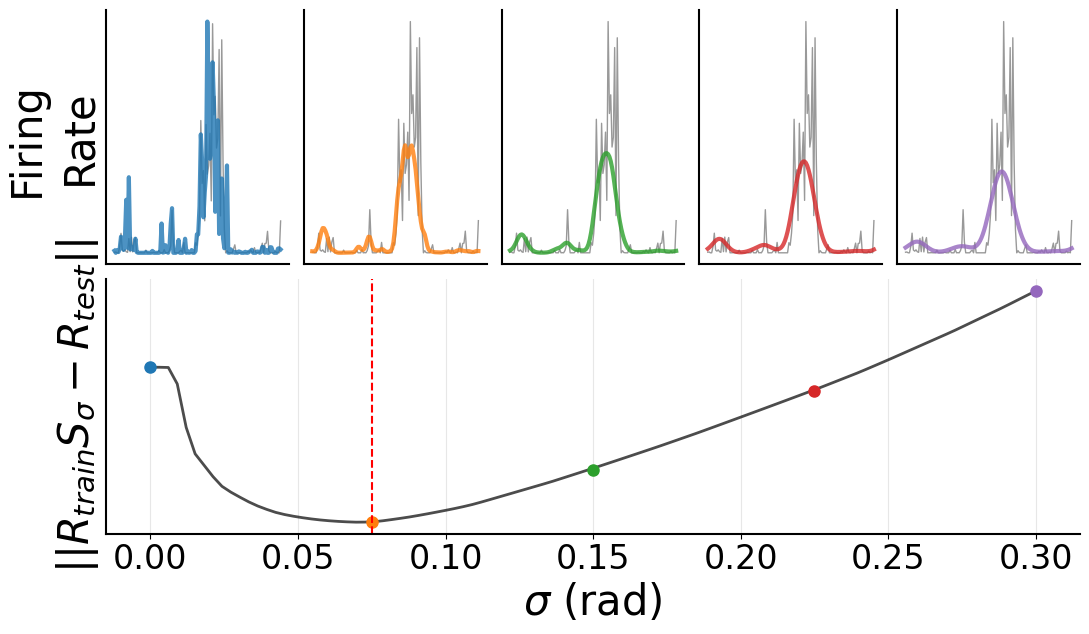

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

cell_no = np.random.randint(0, n_cells)
repeat_no = 0

# Define smoothing values
main_smoothing_strengths = np.array([0.0, 0.075, 0.15, 0.225, 0.3])
fine_smoothing_strengths = np.linspace(0.0, 0.3, 100)

# Color map for smooth transitions
cmap = get_cmap('tab10')
colors = [cmap(i) for i in range(len(main_smoothing_strengths))]

# Prepare figure
fig = plt.figure(figsize=(2.2 * len(main_smoothing_strengths), 7))
gs = fig.add_gridspec(2, len(main_smoothing_strengths), height_ratios=[1, 1])

l1_values_fine = []

# --- Top row: Tuning curves ---
for col, (bw, color) in enumerate(zip(main_smoothing_strengths, colors)):
    ax = fig.add_subplot(gs[0, col])

    # For bw = 0, just use raw repeat 2 (no smoothing)
    if bw == 0.0:
        R_smooth_tmp = R[repeat_no + 1, cell_no, :][None]
        label = "Repeat 2 (raw)"
    else:
        R_smooth_tmp = gaussian_smooth(R[repeat_no + 1, cell_no, :][None], theta=angles, bandwidth_rad=bw)
        label = f"σ = {bw:.3f}"

    # Plot raw (grey) and smoothed (colored)
    ax.plot(angles[::2], R[repeat_no, cell_no, :][::2], color='grey', alpha=0.8, linewidth=1, label='Repeat 1 (raw)')
    ax.plot(angles[::2], R_smooth_tmp[0][::2], color=color, linewidth=3, label=label, alpha=0.8)

    # Compute L1 loss
    l1_loss = np.mean(np.abs(R[repeat_no, cell_no, :] - R_smooth_tmp[0]))

    # ax.set_title(f'bw={bw:.3f}\nL1={l1_loss:.3f}', fontsize=9)
    # ax.set_xlabel(r'$\theta$', fontsize=30)
    ax.set_xticks([])
    ax.set_yticks([])
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # make bottom and left spines thicker
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)

    if col == 0:
        ax.set_ylabel(f'Firing \nRate', fontsize=30)
    # ax.legend(fontsize=8, loc='upper right')

# --- Bottom: L1 loss vs smoothing ---
ax_loss = fig.add_subplot(gs[1, :])

for bw in fine_smoothing_strengths:
    if bw == 0.0:
        R_smooth_tmp = R[repeat_no + 1, cell_no, :][None]
    else:
        R_smooth_tmp = gaussian_smooth(R[repeat_no + 1, cell_no, :][None], theta=angles, bandwidth_rad=bw)
    l1_loss = np.mean(np.abs(R[repeat_no, cell_no, :] - R_smooth_tmp[0]))
    l1_values_fine.append(l1_loss)

ax_loss.plot(fine_smoothing_strengths, l1_values_fine, '-', color='k', alpha=0.7, linewidth=2, label='L1 loss curve')

# Overlay main points
for bw, color in zip(main_smoothing_strengths, colors):
    idx = np.argmin(np.abs(fine_smoothing_strengths - bw))
    ax_loss.plot(bw, l1_values_fine[idx], 'o', color=color, markersize=8)

# Mark the minimal L1 point among the main smoothing strengths
l1_values_main = []
for bw in main_smoothing_strengths:
    if bw == 0.0:
        R_smooth_tmp = R[repeat_no + 1, cell_no, :][None]
    else:
        R_smooth_tmp = gaussian_smooth(R[repeat_no + 1, cell_no, :][None], theta=angles, bandwidth_rad=bw)
    l1_loss = np.mean(np.abs(R[repeat_no, cell_no, :] - R_smooth_tmp[0]))
    l1_values_main.append(l1_loss)
l1_values_main = np.array(l1_values_main)
min_idx = np.argmin(l1_values_main)
ax_loss.axvline(main_smoothing_strengths[min_idx], color='red', linestyle='--', label='Min L1 point')
ax_loss.set_xlabel(r'$\sigma$ (rad)', fontsize=30)
ax_loss.set_ylabel(r'$ || R_{train}S_{\sigma} - R_{test} ||$', fontsize=30)
ax_loss.set_yticks([])
ax_loss.grid(True, alpha=0.3)
# ax_loss.legend(fontsize=18, loc='upper right')
# make sure x and y ticks are fontsize 18
ax_loss.tick_params(axis='both', which='major', labelsize=24)
# remove top and right spines
ax_loss.spines['top'].set_visible(False)
ax_loss.spines['right'].set_visible(False)
# make bottom and left spines thicker
ax_loss.spines['bottom'].set_linewidth(1.5)
ax_loss.spines['left'].set_linewidth(1.5)
# plt.suptitle(f'Cell {cell_no} Responses Across Smoothing Levels', fontsize=30)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
theta1 = params[:, 0]
argsort_theta = np.argsort(theta1)

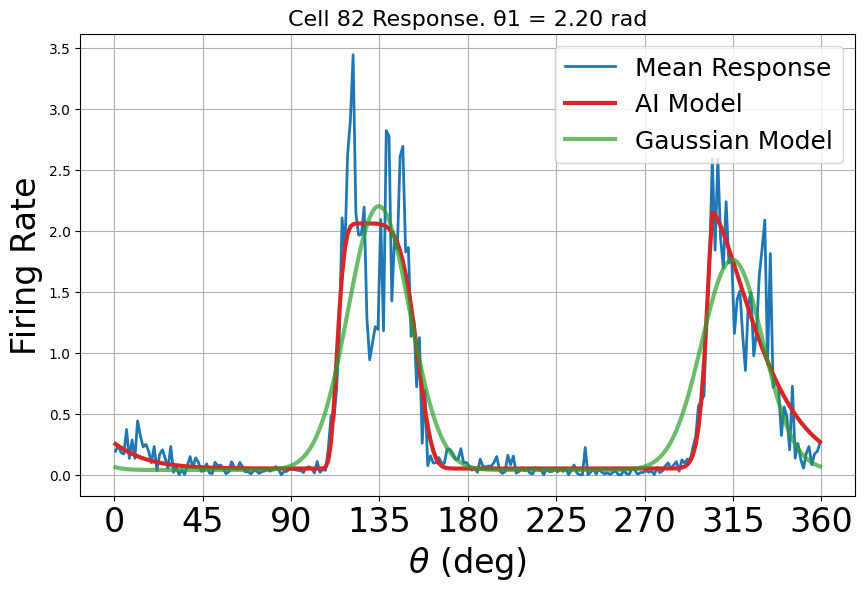

In [22]:
# plot random cell's tuning curve
cell_no = np.random.randint(0, n_cells)
plt.figure(figsize=(10, 6))
plt.plot(angles, R_mean[cell_no], label='Mean Response', color='tab:blue', linewidth=2)
plt.plot(angles, pred[cell_no], label='AI Model', color='tab:red', linewidth=3, alpha=1)
plt.plot(angles, pred_gauss[cell_no], label='Gaussian Model', color='tab:green', linewidth=3, alpha=0.7)
plt.legend(fontsize=18)
plt.xlabel(r'$\theta$ (deg)', fontsize=24)
plt.xticks(ticks=np.linspace(0, 2*np.pi, 9), labels=[f'{int(np.degrees(a))}' for a in np.linspace(0, 2*np.pi, 9)], fontsize=24)
plt.ylabel(r'Firing Rate', fontsize=24)
plt.title(f'Cell {cell_no} Response. θ1 = {theta1[cell_no]:.2f} rad', fontsize=16)
plt.grid()
plt.show()

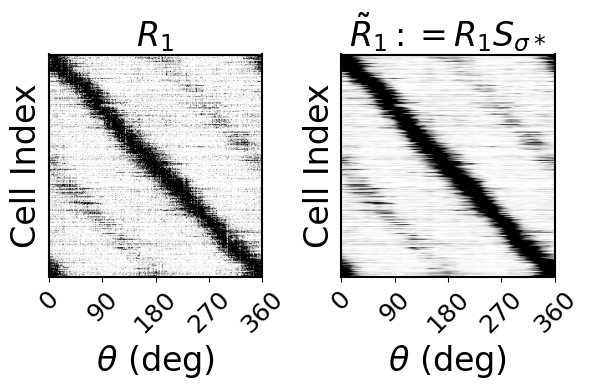

In [19]:
# plot raster map of R and R_smooth
plt.figure(figsize=(6, 4))
plt.subplot(1, 2, 1)
plt.imshow(-R[0][argsort_theta][::5], aspect='auto', cmap='grey', vmin=-np.percentile(R, 90), vmax=-np.percentile(R, 10))
plt.title(r'$R_{1}$', fontsize=24)
plt.xlabel(r'$\theta$ (deg)', fontsize=24)
plt.ylabel('Cell Index', fontsize=24)
plt.xticks([0, n_angles//4, n_angles//2, 3*n_angles//4, n_angles], labels=['0', '90', '180', '270', '360'], fontsize=18, rotation=45)
plt.yticks([])
plt.ylabel('Cell Index', fontsize=24)

plt.subplot(1, 2, 2)
plt.imshow(-R_smooth[0][argsort_theta][::5], aspect='auto', cmap='grey', vmin=-np.percentile(R_smooth, 90), vmax=-np.percentile(R_smooth, 10))
plt.title(r'$\tilde{R}_1 := R_{1} S_{\sigma*}$', fontsize=24)
plt.xlabel(r'$\theta$ (deg)', fontsize=24)
plt.ylabel('Cell Index', fontsize=24)
plt.xticks([0, n_angles//4, n_angles//2, 3*n_angles//4, n_angles], labels=['0', '90', '180', '270', '360'], fontsize=18, rotation=45)
plt.yticks([])
# plt.colorbar(label='Firing Rate')
# make spines thicker
for ax in plt.gcf().axes:
    ax.spines['top'].set_linewidth(1.5)
    ax.spines['right'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
plt.tight_layout()
plt.show()

Number of valid cells: 1037 / 1604


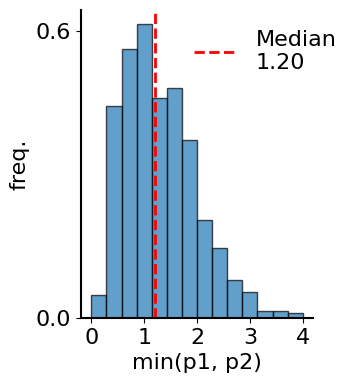

In [387]:
p1 = params[:, 5]
p2 = params[:, 10]
amp1 = params[:, 2]
amp2 = params[:, 7]
valid = amp2 / amp1 > 0.05
print(f"Number of valid cells: {np.sum(valid)} / {n_cells}")
# p = np.concatenate([p1, p2[valid]])
p = np.minimum(p1[valid], p2[valid])

# plot histogram of p
scale_factor = 2.0
plt.figure(figsize=(scale_factor * 1.5, scale_factor * 2))
plt.hist(p, bins=np.linspace(0, 4, 15), color='tab:blue', edgecolor='black', alpha=0.7, density=True)
# # add vline at mean
plt.axvline(np.median(p), color='red', linestyle='--', label=f'Median\n{np.median(p):.2f}', linewidth=2)
plt.legend(fontsize=8 * scale_factor, frameon=False, bbox_to_anchor=(0.4, 1))
plt.xlabel('min(p1, p2)', fontsize=8 * scale_factor)
plt.ylabel('freq.', fontsize=8 * scale_factor)
# make ticks at least 8pt * scale_factor
plt.xticks([0, 1, 2, 3, 4], fontsize=8 * scale_factor)
plt.yticks([0, 0.6], fontsize=8 * scale_factor)
# turn off top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# make bottom and left spines thicker
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.show()


In [16]:
evals_model = np.array(vanilla_cvpca(pred, pred))
evals_model_gauss = np.array(vanilla_cvpca(pred_gauss, pred_gauss))
evals_est = np.array(sym_cvpca(R, R_smooth))
evals_raw = np.array(sym_cvpca(R, R))
# evals_est_raw = np.array(sym_cvpca(R, R))
# evals_est1 = np.array(sym_cvpca(R[:n_repeats//2], R_smooth[:n_repeats//2]))
# evals_est2 = np.array(sym_cvpca(R[n_repeats//2:], R_smooth[n_repeats//2:]))
# evals_list = [evals_est, evals_model, evals_model_gauss]

In [17]:
# Rz = (R - R.mean(axis=1, keepdims=True)) / R.std(axis=1, keepdims=True)
# C_sym = np.zeros((n_angles, n_angles))
# C_sym1 = np.zeros((n_angles, n_angles))
# C_sym2 = np.zeros((n_angles, n_angles))
# for i in range(n_repeats):
#     for j in range(n_repeats):
#         if i == j:
#             continue
#         C_sym += Rz[i].T @ Rz[j] / (n_repeats * (n_repeats - 1))
#         if i < n_repeats // 2 and j < n_repeats // 2:
#             C_sym1 += Rz[i].T @ Rz[j] / ((n_repeats // 2) * (n_repeats // 2 - 1))
#         elif i >= n_repeats // 2 and j >= n_repeats // 2:
#             C_sym2 += Rz[i].T @ Rz[j] / ((n_repeats // 2) * (n_repeats // 2 - 1))

In [18]:
# def cyclic_diagonal_averages(A: np.ndarray) -> np.ndarray:
#     """
#     Returns a vector of length n where each element k
#     is the average of the cyclic (wrapped) diagonal with offset k.
#     For symmetric A, A[i, (i + k) % n] is used.
#     """
#     n = A.shape[0]
#     return np.array([
#         np.mean([A[i, (i + k) % n] for i in range(n)])
#         for k in range(n)
#     ])

In [19]:
# plt.figure(figsize=(15, 6))

# plt.subplot(1, 3, 1)
# plt.imshow(C_sym, cmap='viridis')
# plt.colorbar(label='Covariance', shrink=0.5, aspect=20)
# plt.title('Symmetric Cross-Validated Covariance Matrix', fontsize=16)
# plt.xlabel('Angle Index', fontsize=14)
# plt.ylabel('Angle Index', fontsize=14)

# plt.subplot(1, 3, 2)
# plt.imshow(C_sym1, cmap='viridis')
# plt.colorbar(label='Covariance', shrink=0.5, aspect=20)
# plt.title('Subset 1 Covariance Matrix', fontsize=16)
# plt.xlabel('Angle Index', fontsize=14)
# plt.ylabel('Angle Index', fontsize=14)

# plt.subplot(1, 3, 3)
# plt.imshow(C_sym2, cmap='viridis')
# plt.colorbar(label='Covariance', shrink=0.5, aspect=20)
# plt.title('Subset 2 Covariance Matrix', fontsize=16)
# plt.xlabel('Angle Index', fontsize=14)
# plt.ylabel('Angle Index', fontsize=14)

# plt.tight_layout()
# plt.show()

In [20]:
# kernel = cyclic_diagonal_averages(C_sym)
# kernel1 = cyclic_diagonal_averages(C_sym1)
# kernel2 = cyclic_diagonal_averages(C_sym2)
# plt.figure(figsize=(10, 6))
# plt.plot(np.arange(len(kernel)), np.roll(kernel, n_angles // 2), marker='o', linestyle='-', color='tab:purple', markersize=6, alpha=0.6, label='Full Dataset')
# plt.plot(np.arange(len(kernel1)), np.roll(kernel1, n_angles // 2), marker='o', linestyle='-', color='tab:orange', markersize=6, alpha=0.6, label='Subset 1')
# plt.plot(np.arange(len(kernel2)), np.roll(kernel2, n_angles // 2), marker='o', linestyle='-', color='tab:green', markersize=6, alpha=0.6, label='Subset 2')
# plt.xlabel('Lag', fontsize=16)
# plt.ylabel('Average Covariance', fontsize=16)
# plt.title('Cyclic Diagonal-Averaged Covariance Matrix', fontsize=16)
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend(fontsize=14)
# plt.tight_layout()
# plt.show()

In [21]:
# # compute the fourier coefficients of the kernel
# K_data_ft = np.fft.fftshift(np.fft.fft(kernel))
# K_data1_ft = np.fft.fftshift(np.fft.fft(kernel1))
# K_data2_ft = np.fft.fftshift(np.fft.fft(kernel2))
# # K_model_ft = np.fft.fftshift(np.fft.fft(K_model))
# plt.figure(figsize=(12, 5))
# plt.plot(np.arange(n_angles//2), np.abs(K_data_ft[n_angles//2:]), label='Data Kernel FT', color='blue')
# plt.plot(np.arange(n_angles//2), np.abs(K_data1_ft[n_angles//2:]), label='Subset 1 Kernel FT', color='orange')
# plt.plot(np.arange(n_angles//2), np.abs(K_data2_ft[n_angles//2:]), label='Subset 2 Kernel FT', color='green')
# # plt.plot(np.arange(n_angles//2), np.abs(K_model_ft[n_angles//2:]), label='Model Kernel FT', color='red')
# theta = np.arange(n_angles).astype(float)
# plt.grid()
# plt.xlabel('Fourier Mode')
# plt.ylabel('Fourier Coefficient Magnitude')
# plt.xscale('log')
# plt.yscale('log')
# plt.title('Kernel Fourier Coefficients')
# plt.legend()
# plt.show()

/tmp/ipykernel_3654219/1686547992.py:232: RuntimeWarning: divide by zero encountered in log
  ax.plot(x_vals, np.exp(np.polyval(coeff_loglog, np.log(x_vals))),
/home/reilly/miniconda3/envs/ai_scientist/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:778: RuntimeWarning: invalid value encountered in multiply
  y = y * x + pv


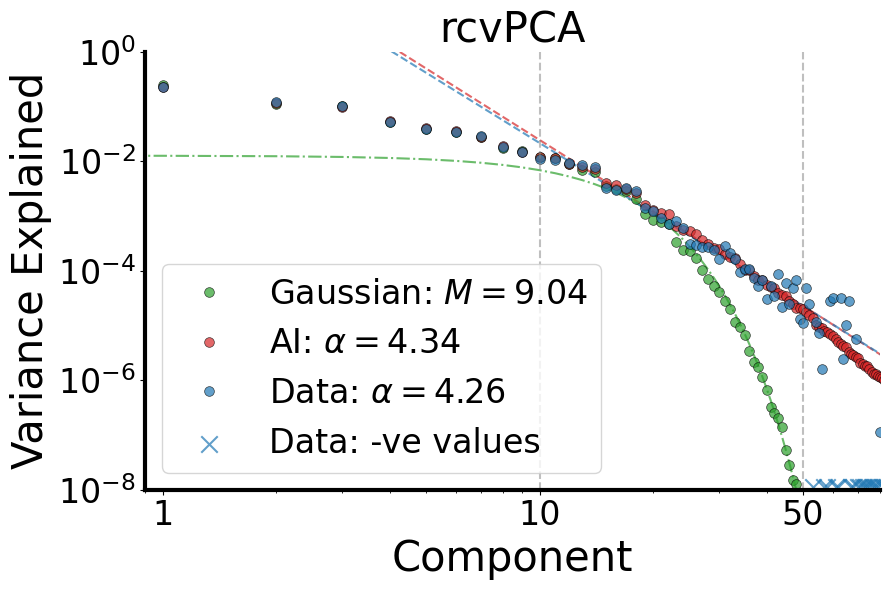

/tmp/ipykernel_3654219/1686547992.py:232: RuntimeWarning: divide by zero encountered in log
  ax.plot(x_vals, np.exp(np.polyval(coeff_loglog, np.log(x_vals))),
/home/reilly/miniconda3/envs/ai_scientist/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:778: RuntimeWarning: invalid value encountered in multiply
  y = y * x + pv


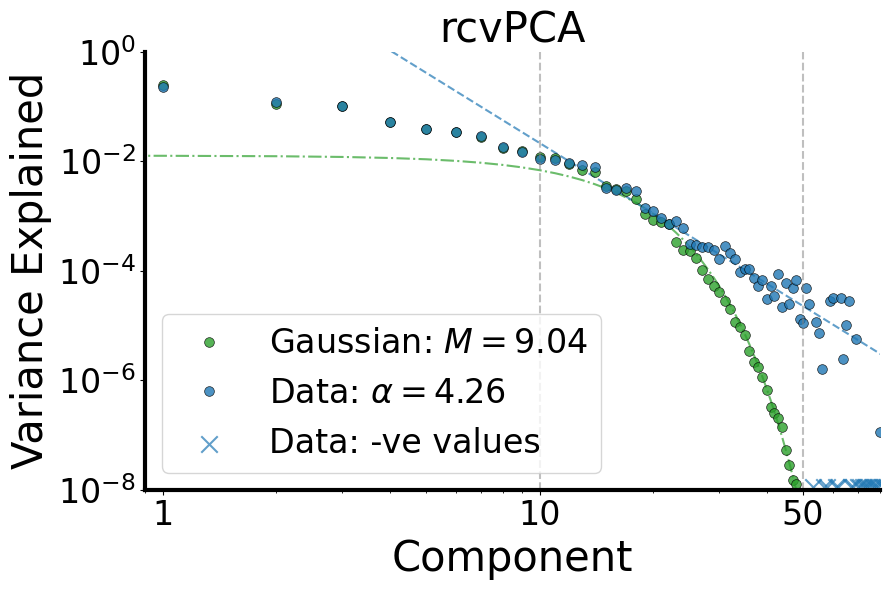

In [36]:
plot_min, plot_max = 0.9, 80
fit_min, fit_max = 10, 50
plot_evals_with_mse_table(
    [evals_model_gauss, 
     evals_model, 
     evals_est],
    labels=['Gaussian', 
            'AI', 
            'Data'],
    fit_range=(fit_min, fit_max),
    fit_line=[True, 
              True, 
              True],  # Fit all three, or disable for Gaussian if you like
    fit_type=['quadratic', 
              'loglog', 
              'loglog'],  # Gaussian often fits better quadratically
    markersize=2.5,
    colors=['tab:green', 
            'tab:red', 
            'tab:blue'],
    alpha=0.7,
    y_lim=(1e-8, 1),
    x_lim=(plot_min, plot_max),
    plot_negative=[False, 
                   False, 
                   True],
    legend_loc='lower left',
    fontsize=8,
    title='rcvPCA',
    rectangle_coords=(0.125, 0.04, 0.4, 0.22),
    plot_table=False,
    scale_factor=3.0
)

plot_evals_with_mse_table(
    [evals_model_gauss, evals_est],
    labels=['Gaussian', 'Data'],
    fit_range=(fit_min, fit_max),
    fit_line=[True, True],
    fit_type=['quadratic', 'loglog'],
    markersize=2.5,
    colors=['tab:green', 'tab:blue'],
    alpha=0.8,
    y_lim=(1e-8, 1),
    x_lim=(plot_min, plot_max),
    plot_negative=[False, True],
    legend_loc='lower left',
    fontsize=8,
    title='rcvPCA',
    rectangle_coords=(0.125, 0.04, 0.4, 0.22),
    plot_table=False,
    scale_factor=3.0
)

# plot_evals_with_mse_table(
#     [evals_model, 
#      evals_est],
#         labels=['ground truth', 
#                 'ground truth + noise'],
#     fit_range=(fit_min, fit_max),
#     fit_line=[True, 
#               True],  # Fit all three, or disable for Gaussian if you like
#     fit_type=['loglog', 
#               'loglog'],  # Gaussian often fits better quadratically
#     markersize=6,
#     colors=['tab:blue', 
#             'tab:orange'],
#     alpha=0.8,
#     y_lim=(1e-7, 1),
#     x_lim=(plot_min, plot_max),
#     plot_negative=[False, 
#                    True],
#     legend_loc='upper right',
#     fontsize=16,
#     title='rcvPCA Simulation Results',
#     rectangle_coords=(0.125, 0.04, 0.4, 0.22),
#     plot_table=False
# )

# plot_evals_with_mse_table(
#     [evals_model,
# #      evals_raw,
#      evals_est],
#     labels=['Ground Truth',
#         #     r'Ground Truth + Noise (cvPCA) $\alpha = 2.68$',
#             'Ground Truth + Noise (rcvPCA)'],
#     fit_range=(fit_min, fit_max),
#     fit_line=[True,
#         #       False,
#               True],
#     fit_type=['loglog',
#         #       'loglog',
#               'loglog'],
#     markersize=6,
#     colors=['tab:grey',
#         #     'tab:blue',
#             'tab:red'],
#     alpha=0.8,
#     y_lim=(1e-7, 1),
#     x_lim=(plot_min, plot_max),
#     plot_negative=[False,
#                 #    False,
#                    True],
#     legend_loc='lower left',
#     fontsize=16,
#     title='rcvPCA Simulation',
#     plot_table=False,
# )

In [46]:
# n_repeats_sim = 3
# R_sim = np.zeros((n_repeats_sim, n_cells, n_angles))
# for rep in range(n_repeats_sim):
#     R_sim[rep] = pred + np.random.randn(n_cells, n_angles) * noise_level
# # R_sim = np.clip(R_sim, a_min=0, a_max=None)

# # smooth each repeat
# R_sim_smooth = np.zeros_like(R_sim)
# for rep in range(0, n_repeats_sim):
#     preds, fracs = fit_lowess(
#         R_full=R_sim[rep],
#         theta_full=angles,
#         frac_values=frac_values,
#         n_folds=2
#     )
#     R_sim_smooth[rep] = preds
#     print(f"Session {rep + 1} done")

In [47]:
# # normalise so each cell has mean 0 and std 1
# R_mean_z = (R_mean - np.mean(R_mean, axis=-1, keepdims=True)) / np.std(R_mean, axis=-1, keepdims=True)
# R_smooth_mean_z = (R_smooth_mean - np.mean(R_smooth_mean, axis=-1, keepdims=True)) / np.std(R_smooth_mean, axis=-1, keepdims=True)
# pred_z = (pred - np.mean(pred, axis=-1, keepdims=True)) / np.std(pred, axis=-1, keepdims=True)
# pred_gauss_z = (pred_gauss - np.mean(pred_gauss, axis=-1, keepdims=True)) / np.std(pred_gauss, axis=-1, keepdims=True)

# # get left singular vectors of R_smooth, pred and pred_gauss
# U_data_smooth, _, _ = np.linalg.svd(R_smooth_mean_z, full_matrices=False)
# U_pred_gauss, _, _ = np.linalg.svd(pred_gauss_z, full_matrices=False)
# U_pred, _, _ = np.linalg.svd(pred_z, full_matrices=False)

In [48]:
# # average each response at angle theta with angle theta + pi
# R_double = (R[:, :, :n_angles//2] + R[:, :, n_angles//2:])/2
# R_double_smooth = (R_smooth[:, :, :n_angles//2] + R_smooth[:, :, n_angles//2:])/2
# pred_double = (pred[:, :n_angles//2] + pred[:, n_angles//2:])/2
# pred_gauss_double = (pred_gauss[:, :n_angles//2] + pred_gauss[:, n_angles//2:])/2
# # R_double = R[:, :, :n_angles//2]
# # R_double_smooth = R_smooth[:, :, :n_angles//2]
# # pred_double = pred[:, :n_angles//2]
# # pred_gauss_double = pred_gauss[:, :n_angles//2]

# # downsample each of these matrices
# downsample_factor = 4
# n_orientations = n_angles // (2 * downsample_factor)
# R_double = R_double.reshape(n_repeats, n_cells, (n_angles//2) // downsample_factor, downsample_factor).mean(axis=-1)
# R_double_smooth = R_double_smooth.reshape(n_repeats, n_cells, (n_angles//2) // downsample_factor, downsample_factor).mean(axis=-1)
# # n_shuffles = 100
# # R_double_smooth_shuffles = np.zeros((n_shuffles, n_repeats, n_cells, n_orientations))
# # for i in range(n_shuffles):
# #     for theta in range(n_orientations):
# #         coin_flip = np.random.randint(2)
# #         R_double_smooth_shuffles[i, :, :, theta] = R_double_smooth[:, :, 2 * theta + coin_flip]
# # R_smooth_train = R_double_smooth_shuffles[:, 0]
# pred_double = pred_double.reshape(n_cells, (n_angles//2) // downsample_factor, downsample_factor).mean(axis=-1)
# pred_gauss_double = pred_gauss_double.reshape(n_cells, (n_angles//2) // downsample_factor, downsample_factor).mean(axis=-1)

# #  normalise so each cell has mean 0
# R_z = R_double - np.mean(R_double, axis=-1, keepdims=True)
# R_smooth_z = R_double_smooth - np.mean(R_double_smooth, axis=-1, keepdims=True)
# # R_smooth_z = R_double_smooth_shuffles - np.mean(R_double_smooth_shuffles, axis=-1, keepdims=True)
# pred_z = pred_double - np.mean(pred_double, axis=-1, keepdims=True)
# pred_gauss_z = pred_gauss_double - np.mean(pred_gauss_double, axis=-1, keepdims=True)
# # R_smooth_train_z = R_smooth_train - np.mean(R_smooth_train, axis=-1, keepdims=True)

# # normalise so each cell has std 1
# R_z = R_z / (np.std(R_z, axis=-1, keepdims=True) + 1e-10)
# R_smooth_z = R_smooth_z / (np.std(R_smooth_z, axis=-1, keepdims=True) + 1e-10)
# pred_z = pred_z / (np.std(pred_z, axis=-1, keepdims=True) + 1e-10)
# pred_gauss_z = pred_gauss_z / (np.std(pred_gauss_z, axis=-1, keepdims=True) + 1e-10)
# # R_smooth_train_z = R_smooth_train_z / (np.std(R_smooth_train_z, axis=-1, keepdims=True) + 1e-10)

# # get left singular vectors of R_smooth, pred and pred_gauss
# U_data, _, _ = np.linalg.svd(R_smooth_z, full_matrices=False)
# U_pred_gauss, _, _ = np.linalg.svd(pred_gauss_z, full_matrices=False)
# U_pred, _, _ = np.linalg.svd(pred_z, full_matrices=False)

In [49]:
# n_orientations = n_angles // 2
# orientations = angles[::2]
# z_dim = 24

# # average over angles theta and theta + pi
# R_double = (R_smooth[:, :, :n_angles//2] + R_smooth[:, :, n_angles//2:])/2
# # R_double = R_double.mean(axis=0)
# R_double_raw = (R[:, :, :n_angles//2] + R[:, :, n_angles//2:])/2
# pred_double = (pred[:, :n_angles//2] + pred[:, n_angles//2:])/2
# pred_gauss_double = (pred_gauss[:, :n_angles//2] + pred_gauss[:, n_angles//2:])/2

# # normalise so each cell has mean 0 and std 1
# R_double_z = (R_double - np.mean(R_double, axis=-1, keepdims=True)) / (np.std(R_double, axis=-1, keepdims=True) + 1e-10)
# R_double_raw_z = (R_double_raw - np.mean(R_double_raw, axis=-1, keepdims=True)) / (np.std(R_double_raw, axis=-1, keepdims=True) + 1e-10)
# pred_double_z = (pred_double - np.mean(pred_double, axis=-1, keepdims=True)) / (np.std(pred_double, axis=-1, keepdims=True) + 1e-10)
# pred_gauss_double_z = (pred_gauss_double - np.mean(pred_gauss_double, axis=-1, keepdims=True)) / (np.std(pred_gauss_double, axis=-1, keepdims=True) + 1e-10)

# # now we are going to get to get eigenvectors from every 3rd repeat of R_double_z, and project the following 2 repeats onto these eigenvectors
# # U_data = []
# # for i in range(downsample_factor):
# #     U, _, _ = np.linalg.svd(R_double_z[3 * i], full_matrices=False)
# #     U_data.append(U)
# U_data, _, _ = np.linalg.svd(R_double_z, full_matrices=False)
# U_pred, _, _ = np.linalg.svd(pred_double_z, full_matrices=False)
# U_pred_gauss, _, _ = np.linalg.svd(pred_gauss_double_z, full_matrices=False)

# # define projection matrices
# P_data = U_data[:, :, [0, 1, z_dim - 1]] # (n_repeats, n_cells, 3)
# # P_data = U_data[:, [0, 1, z_dim - 1]] # (n_cells, 3)
# P_pred = U_pred[:, [0, 1, z_dim - 1]] # (n_cells, 3)
# P_pred_gauss = U_pred_gauss[:, [0, 1, z_dim - 1]] # (n_cells, 3)

# MP = pred_double_z.T @ P_pred  # (n_orientations, 3)
# GP = pred_gauss_double_z.T @ P_pred_gauss  # (n_orientations, 3)
# # RP = R_double_z.T @ P_data  # (n_orientations, 3)
# RP = np.zeros((n_repeats, n_orientations, 3))  # (n_repeats, n_orientations, 3)
# for i in range(n_repeats):
#     RP[i] = R_double_z[i].T @ P_data[i]  # (n_orientations, 3)

# # connect the ends of each curve to make a loop
# MP = np.vstack([MP, MP[0]])
# GP = np.vstack([GP, GP[0]])
# # RP = np.vstack([RP, RP[0]])
# RP = np.concatenate([RP, RP[:, :1]], axis=1)


In [50]:
# smooth R_double by a binary search, where we pick the bandwidth that minimises cross-validated MAE
# --- Parameters ---
bw_min, bw_max = 0.0, 1.0
tol = 1e-4          # stop when search interval is small
max_iter = 16       # number of binary search iterations

# R_double = R_double.reshape(n_repeats // 2, 2, n_cells, n_angles // 2).mean(axis=1)
n_repeats_double = R_double.shape[0]
n_angles_double = R_double.shape[2]
print(f"n_repeats_double: {n_repeats_double}, n_cells: {n_cells}, n_angles_double: {n_angles_double}")
R_double_smooth = np.zeros_like(R_double)
# --- Helper: compute cross-validated MSE across distinct sessions ---
def evaluate_bw_double(R_double, bw, mae: bool = True):
    """Smooth all repeats with given bandwidth and compute mean cross-validated MSE.
    if mae=True, return MAE instead of MSE.
    """
    R_smooth_tmp = np.zeros_like(R_double)

    # Smooth all repeats
    for session in range(n_repeats_double):
        R_smooth_tmp[session] = gaussian_smooth(R_double[session], theta=angles_double, bandwidth_rad=bw)

    # Cross-validated MAE across distinct session pairs
    mae_vals = []
    mse_vals = []
    for c in range(n_cells):
        for i in range(n_repeats_double):
            for j in range(n_repeats_double):
                if i == j:
                    continue  # distinct sessions only
                diff = R_smooth_tmp[i, c, :] - R_double[j, c, :]
                mae_vals.append(np.nanmean(np.abs(diff)))
                mse_vals.append(np.nanmean(diff**2))
    mae_vals = np.array(mae_vals)
    mse_vals = np.array(mse_vals)
    return np.nanmean(mae_vals) if mae else np.nanmean(mse_vals)

# --- Binary search for MAE minimum ---
low, high = bw_min, bw_max
best_frac, best_loss = None, np.inf
for it in range(max_iter):
    mid = (low + high) / 2
    delta = (high - low) / 4  # small perturbation for left/right comparisons

    left_bw = max(bw_min, mid - delta)
    right_bw = min(bw_max, mid + delta)

    loss_left = evaluate_bw_double(R_double, left_bw)
    loss_right = evaluate_bw_double(R_double, right_bw)
    print(f"Iter {it+1}: left={left_bw:.4f} Loss={loss_left:.6f}, right={right_bw:.4f} Loss={loss_right:.6f}")

    # Move toward side with lower MAE
    if loss_left < loss_right:
        high = mid
        best_bw, best_loss = left_bw, loss_left
    else:
        low = mid
        best_bw, best_loss = right_bw, loss_right

    if abs(high - low) < tol:
        break
print(f"\nBest bw ≈ {best_bw:.4f} (mean cross-val Loss={best_loss:.6f})")
# --- Final smoothing with best bw ---
for session in tqdm(range(n_repeats_double), desc=f"Final smoothing (bw={best_bw:.4f})"):
    R_double_smooth[session] = gaussian_smooth(R_double[session], theta=angles_double, bandwidth_rad=best_bw)

# R_double_smooth = R_double_smooth.reshape(n_repeats // 2, 2, n_cells, n_angles // 2).mean(axis=1)

n_repeats_double: 6, n_cells: 582, n_angles_double: 128
Iter 1: left=0.2500 Loss=0.227800, right=0.7500 Loss=0.319451
Iter 2: left=0.1250 Loss=0.224149, right=0.3750 Loss=0.243904
Iter 3: left=0.0625 Loss=0.233080, right=0.1875 Loss=0.223899
Iter 4: left=0.1562 Loss=0.223390, right=0.2188 Loss=0.225419
Iter 5: left=0.1406 Loss=0.223587, right=0.1719 Loss=0.223506
Iter 6: left=0.1641 Loss=0.223411, right=0.1797 Loss=0.223670
Iter 7: left=0.1602 Loss=0.223391, right=0.1680 Loss=0.223449
Iter 8: left=0.1582 Loss=0.223388, right=0.1621 Loss=0.223399
Iter 9: left=0.1572 Loss=0.223388, right=0.1592 Loss=0.223389
Iter 10: left=0.1567 Loss=0.223389, right=0.1577 Loss=0.223388
Iter 11: left=0.1575 Loss=0.223388, right=0.1580 Loss=0.223388
Iter 12: left=0.1578 Loss=0.223388, right=0.1581 Loss=0.223388
Iter 13: left=0.1578 Loss=0.223388, right=0.1579 Loss=0.223388
Iter 14: left=0.1579 Loss=0.223388, right=0.1579 Loss=0.223388

Best bw ≈ 0.1579 (mean cross-val Loss=0.223388)


Final smoothing (bw=0.1579): 100%|██████████| 6/6 [00:00<00:00, 1362.08it/s]


In [51]:
z_dim = 24

# normalise so each cell has mean 0 and std 1
R_double_smooth_z = (R_double_smooth - np.mean(R_double_smooth, axis=-1, keepdims=True)) / (np.std(R_double_smooth, axis=-1, keepdims=True) + 1e-10)
pred_double_z = (pred_double - np.mean(pred_double, axis=-1, keepdims=True)) / (np.std(pred_double, axis=-1, keepdims=True) + 1e-10)
pred_gauss_double_z = (pred_gauss_double - np.mean(pred_gauss_double, axis=-1, keepdims=True)) / (np.std(pred_gauss_double, axis=-1, keepdims=True) + 1e-10)

# get eigenvectors
U_data, _, _ = np.linalg.svd(R_double_smooth_z, full_matrices=False)
U_pred, _, _ = np.linalg.svd(pred_double_z, full_matrices=False)
U_pred_gauss, _, _ = np.linalg.svd(pred_gauss_double_z, full_matrices=False)

# define projection matrices
P_data = U_data[:, :, [0, 1, z_dim - 1]] # (n_repeats, n_cells, 3)
P_pred = U_pred[:, [0, 1, z_dim - 1]] # (n_cells, 3)
P_pred_gauss = U_pred_gauss[:, [0, 1, z_dim - 1]] # (n_cells, 3)

# project responses
MP = pred_double_z.T @ P_pred  # (n_orientations, 3)
GP = pred_gauss_double_z.T @ P_pred_gauss  # (n_orientations, 3)
# MP = pred_z.T @ P_data[0]  # (n_orientations, 3)
# GP = pred_gauss_z.T @ P_data[0]  # (n_orientations, 3)
RP = np.zeros((n_repeats_double, n_angles // 2, 3))  # (n_repeats, n_orientations, 3)
for i in range(n_repeats_double):
    # RP[i] = R_z[i].T @ P_data[0]  # (n_orientations, 3)
    RP[i] = R_double_smooth_z[i].T @ P_data[i]  # (n_orientations, 3)

# connect the ends of each curve to make a loop
MP = np.vstack([MP, MP[0]])
GP = np.vstack([GP, GP[0]])
RP = np.concatenate([RP, RP[:, :1]], axis=1)

# loop through the repeats > 0, and try reflect axes 0, 1 and 2 independently to be close to repeat 0
for i in range(1, n_repeats_double):
    # compute distances for all 8 combinations of reflections
    best_dist = np.inf
    for j, signs in enumerate([(1, 1, 1),
                                 (1, 1, -1),
                                 (1, -1, 1),
                                 (1, -1, -1),
                                 (-1, 1, 1),
                                 (-1, 1, -1),
                                 (-1, -1, 1),
                                 (-1, -1, -1)]):
        RP_reflected = RP[i] * np.array(signs)[None, :]
        dist = np.sum((RP_reflected - RP[0])**2)
        if j == 0 or dist < best_dist:
            best_dist = dist
            best_RP = RP_reflected
    RP[i] = best_RP

In [ ]:
# lambda_data = [vanilla_cvpca(R_double_z[i], R_double_z[i]) for i in range(n_repeats)]
# lambda_data = vanilla_cvpca(R_double_z, R_double_z)
# lambda_pred = vanilla_cvpca(pred_double_z, pred_double_z)
# lambda_pred_gauss = vanilla_cvpca(pred_gauss_double_z, pred_gauss_double_z)
# # plot_evals(evals_list=[lambda_data] + [lambda_pred, lambda_pred_gauss],
# #             labels=['Data (vanilla cvPCA)'] + ['Prediction', 'Gaussian Prediction'],
# #             colors=['blue', 'red', 'green'],
# #             title='Eigenvalues of Different Tuning Curve Models',
# #             fit_line=[True, True, False],
# #             plot_negative=True,
# #             fit_range=(10, 30),
# #             x_lim=(1, 100),
# #           #   y_lim=(1e-8, 1e2),
# #             fontsize=12)
# lambda_data = [vanilla_cvpca(R_z[i], R_z[i]) for i in range(n_repeats)]
# lambda_pred = vanilla_cvpca(pred_z, pred_z)
# lambda_pred_gauss = vanilla_cvpca(pred_gauss_z, pred_gauss_z)
# plot_evals(evals_list=lambda_data + [lambda_pred, lambda_pred_gauss],
#             labels=['R0', 'R1', 'R2', 'Prediction', 'Gaussian Prediction'],
#             colors=['royalblue']* n_repeats + ['red', 'green'],
#             title='Eigenvalues of Different Tuning Curve Models',
#             fit_line=[True]* n_repeats + [True, False],
#             plot_negative=True,
#             fit_range=(10, 30),
#             x_lim=(1, 100),
#             y_lim=(1e-9, 1e2),
#             fontsize=12)
# # lambda_data_cv = sym_cvpca(R_double_raw_z, R_double)
# # plot_evals(evals_list=lambda_data_cv + [lambda_pred, lambda_pred_gauss],
# #             labels=['Data (cvPCA)'] + ['Prediction', 'Gaussian Prediction'],
# #             colors=['blue', 'red', 'green'],
# #             title='Eigenvalues of Different Tuning Curve Models',
# #             fit_line=[True, True, False],
# #             plot_negative=True,
# #             fit_range=(10, 30),
# #             x_lim=(1, 100),
# #           #   y_lim=(1e-8, 1e2),
# #             fontsize=12)

In [53]:
# V = np.zeros((2 * 256, n_orientations))  # (N_basis, N_orientations)
# # V = np.zeros((2 * 256, n_angles))  # (N_basis, n_angles)
# for i in  range(1, V.shape[0] // 2 + 1):
#     V[2 * i - 2] = np.cos(i * orientations) / np.sqrt((np.cos(i * orientations) ** 2).sum())
#     V[2 * i - 1] = np.sin(i * orientations) / np.sqrt((np.sin(i * orientations) ** 2).sum())
#     # V[2 * i - 2] = np.cos(i * angles) / np.sqrt((np.cos(i * angles) ** 2).sum())
#     # V[2 * i - 1] = np.sin(i * angles) / np.sqrt((np.sin(i * angles) ** 2).sum())

# def project_onto(R, V, dims=[0, 1, 2]):
#     """
#     Project data R (N_cells, N_angles) onto orthonormal basis V (N_basis, N_angles). Return the projection onto the specified dims.
#     """
#     N_cells = R.shape[0]
#     W = R @ V.T # (N_cells, N_basis)
#     W_tilde = W[:, dims] # (N_cells, len(dims))
#     RP = R.T @ W_tilde / N_cells # (N_angles, len(dims))
#     # connect the ends of each curve to make a loop
#     RP = np.vstack([RP, RP[0]])
#     return RP


In [120]:
# z_dim = 30
# RP = np.array([project_onto(R_double_z[i], V, dims=[0, 1, z_dim - 1]) for i in range(n_repeats)])
# MP = project_onto(pred_double_z, V, dims=[0, 1, z_dim - 1])
# GP = project_onto(pred_gauss_double_z, V, dims=[0, 1, z_dim - 1])
# # now plot MP, GP and RP
# plot_point_clouds_3d(
#     clouds = [RP[i] for i in range(n_repeats)] + [MP, GP],
#     colors=['blue']*n_repeats + ['red', 'green'],
#     labels=[f'Response Repeat {i+1}' for i in range(n_repeats)] + ['Prediction', 'Gaussian Prediction'],
#     floor_dist=0.5,
#     band_alpha=0.1,
#     axis_alpha=0.6,
#     title='3D Projections of Neural Responses and Model Predictions',
#     z_label=f'mode {z_dim}',
#     figsize=(10, 8)
# )

0 1


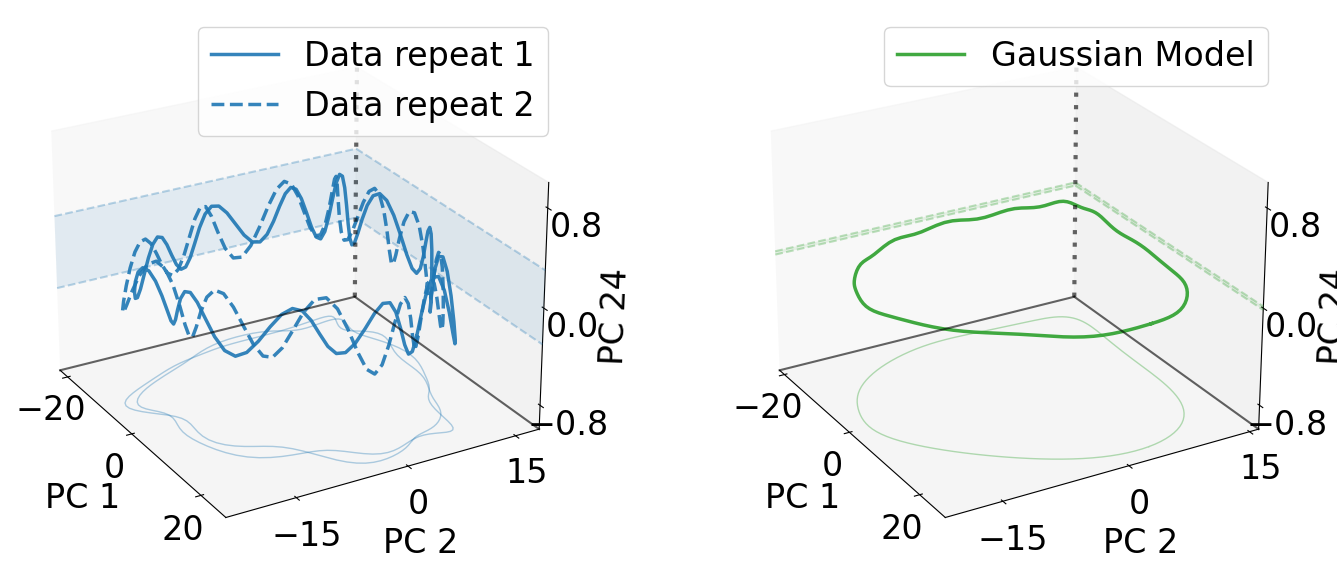

0 2


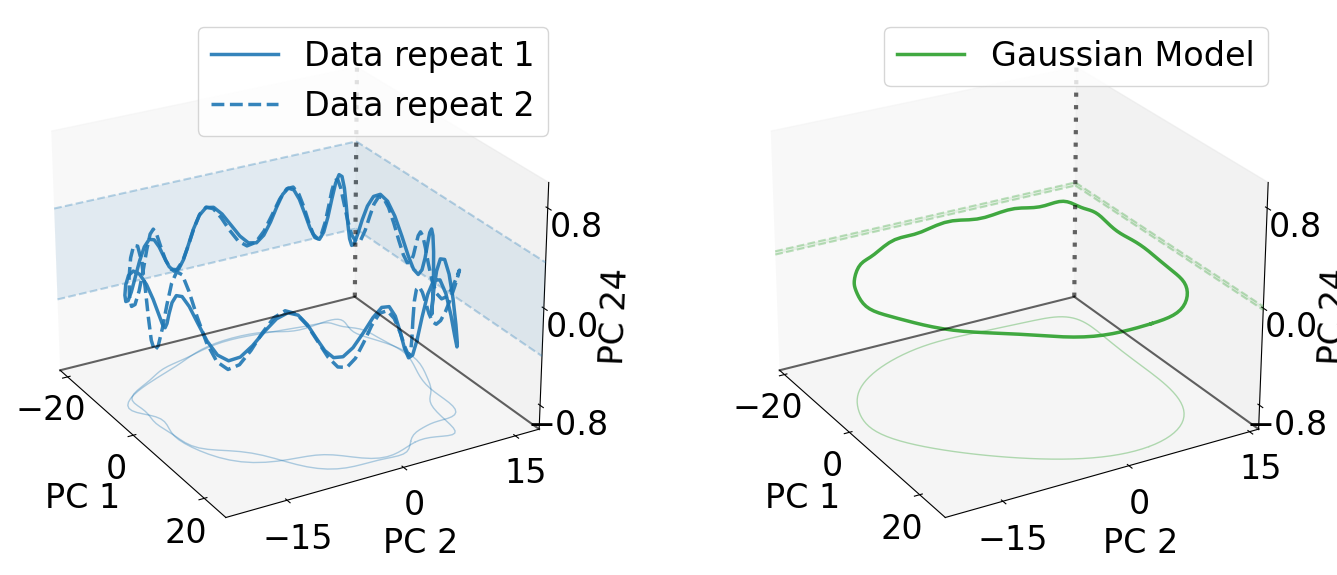

0 3


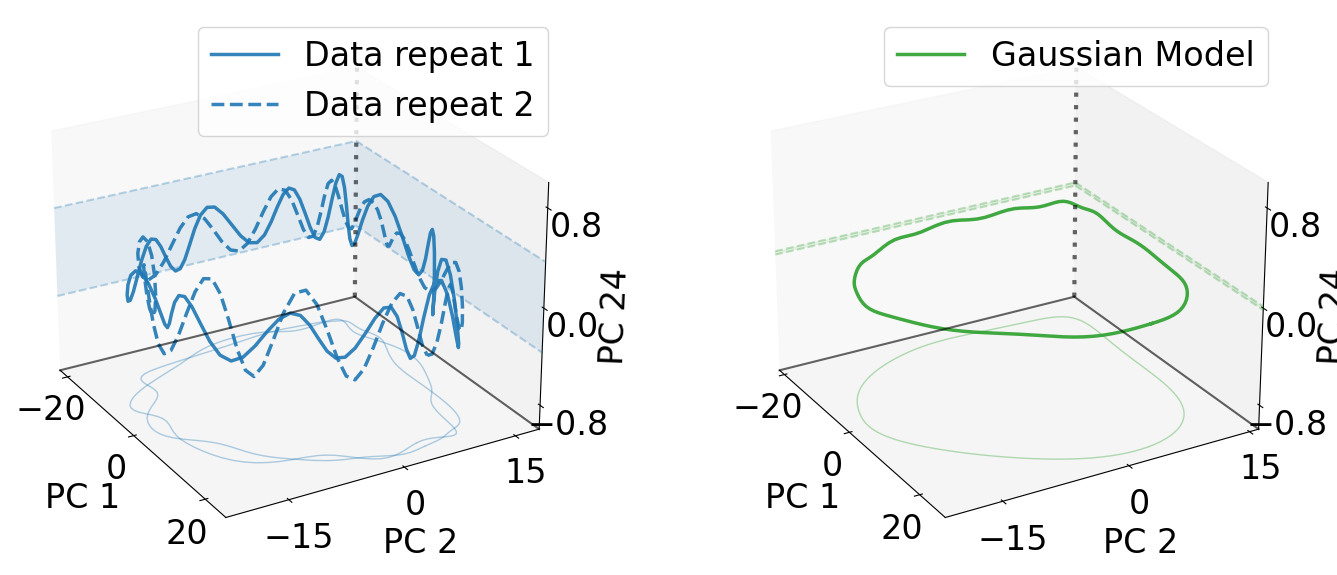

0 4


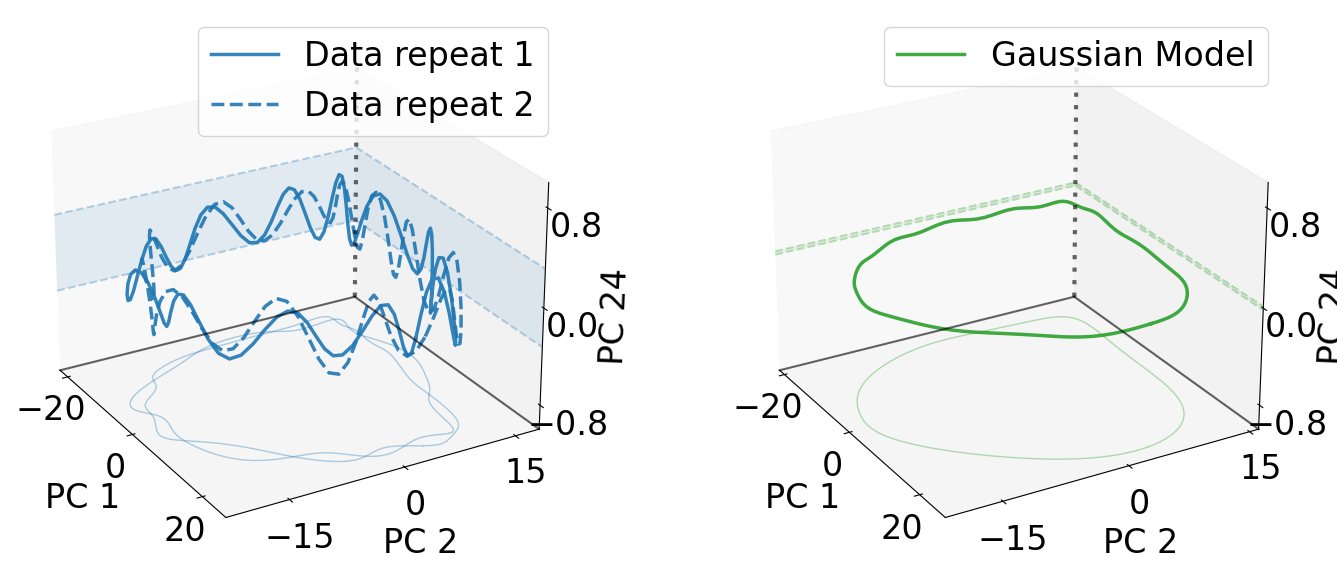

0 5


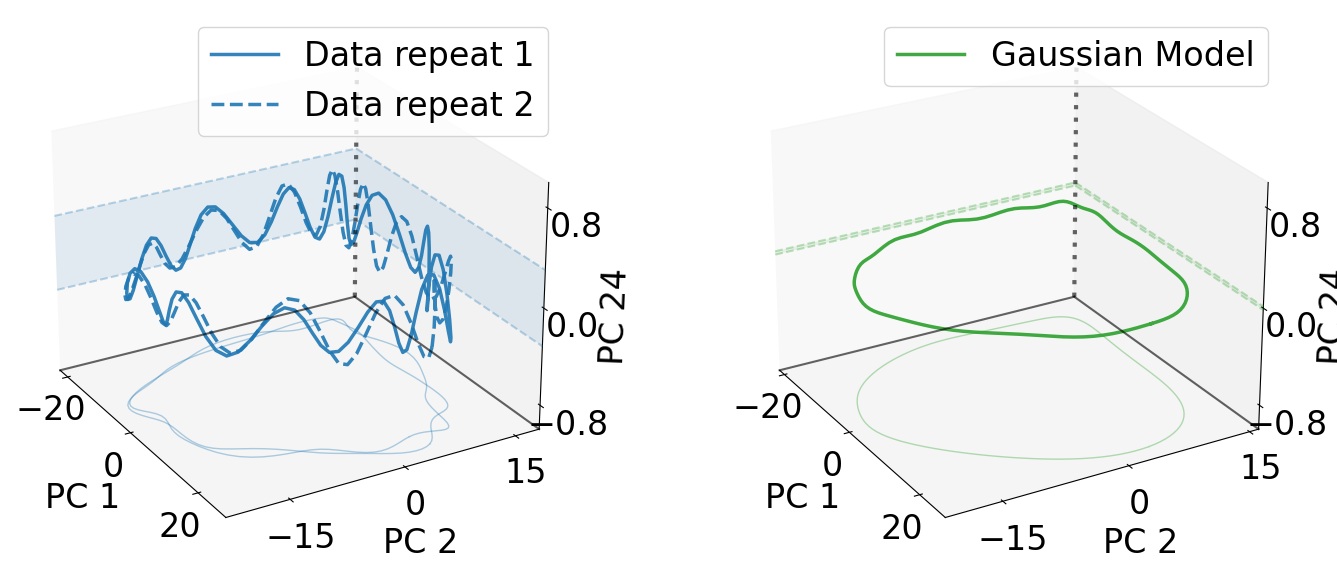

1 2


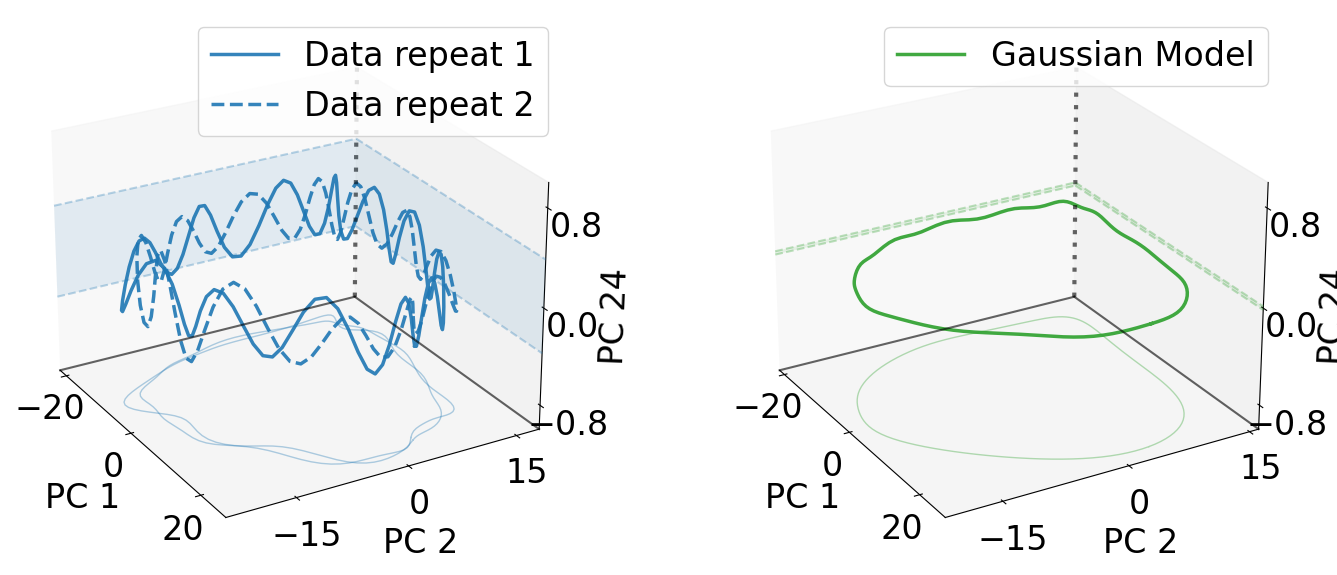

1 3


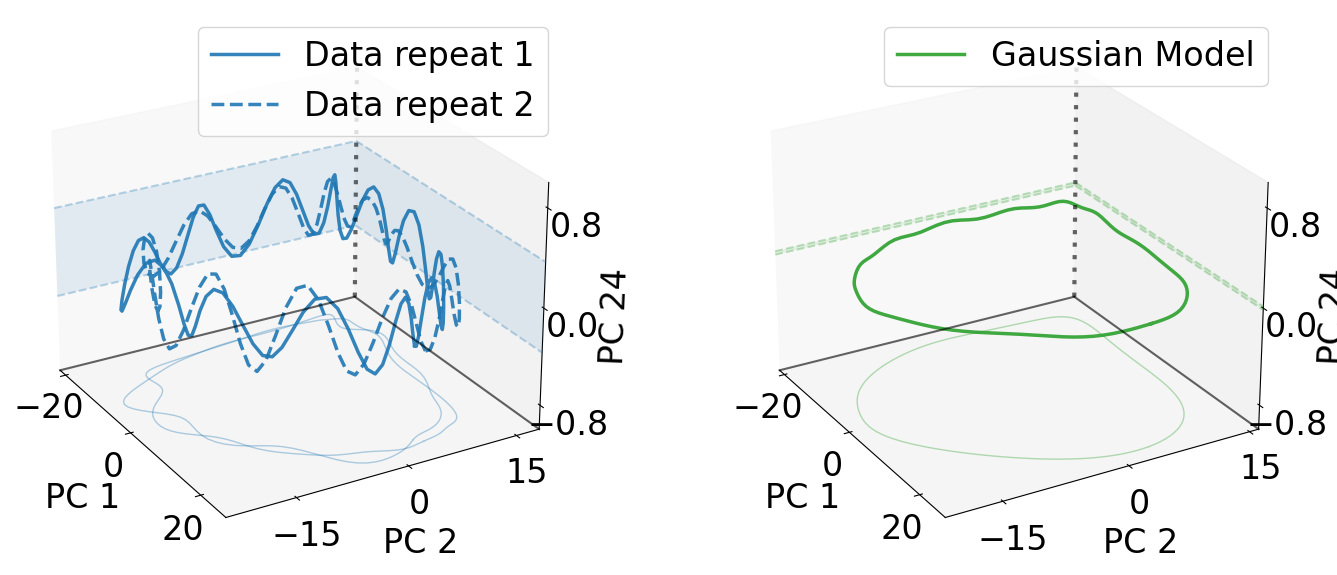

1 4


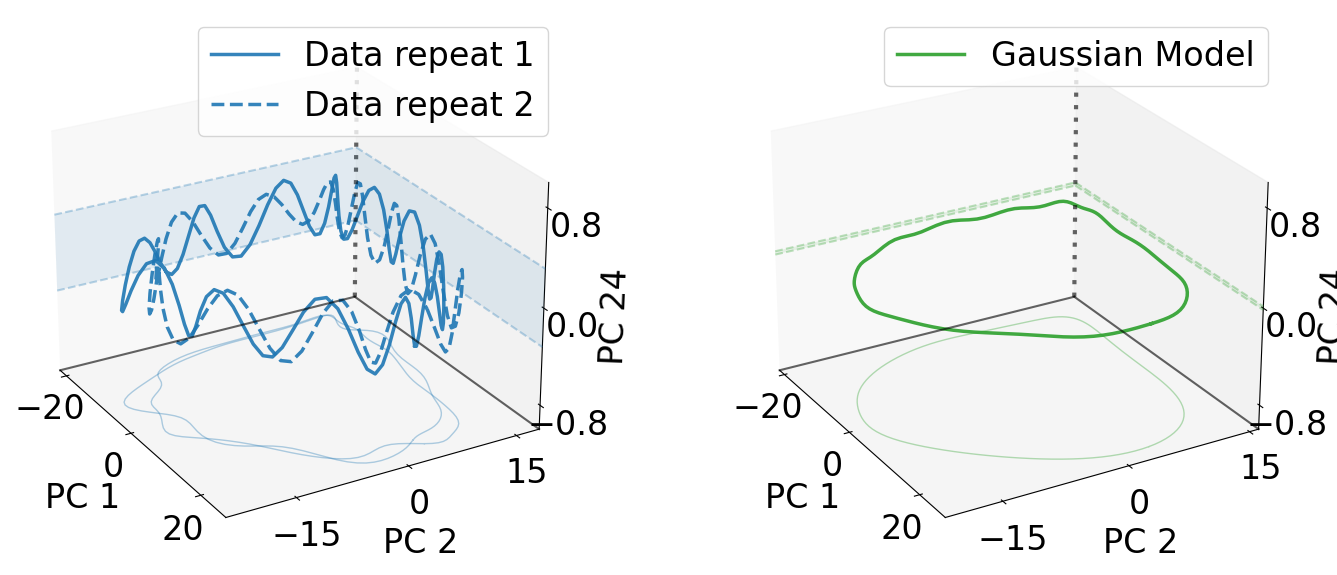

1 5


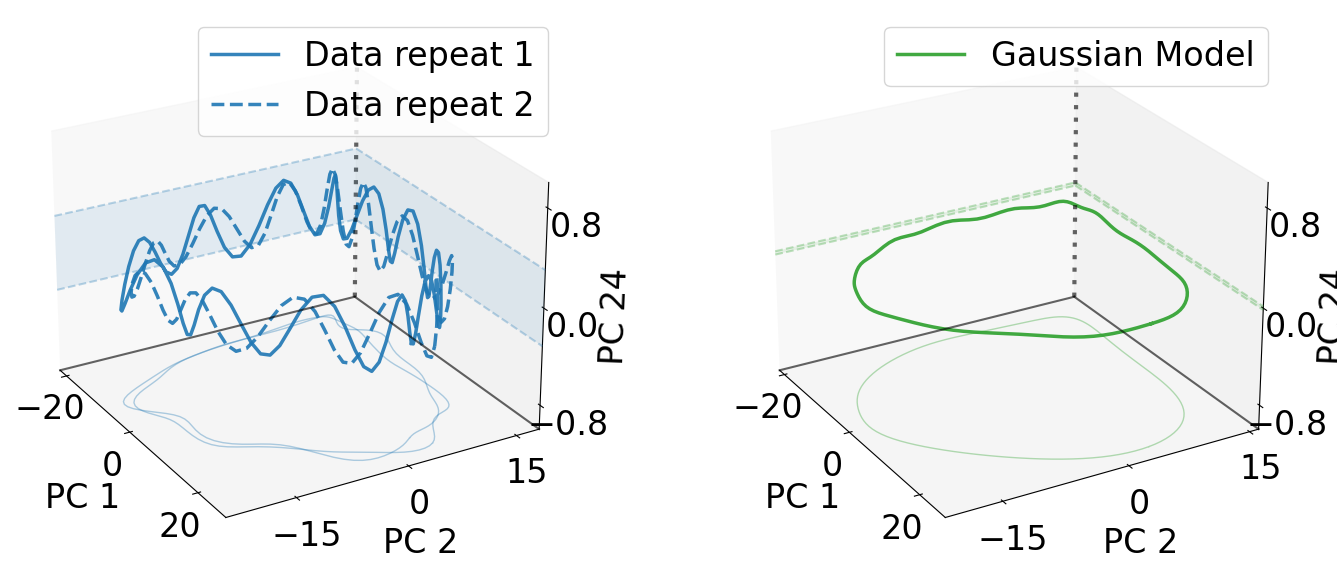

2 3


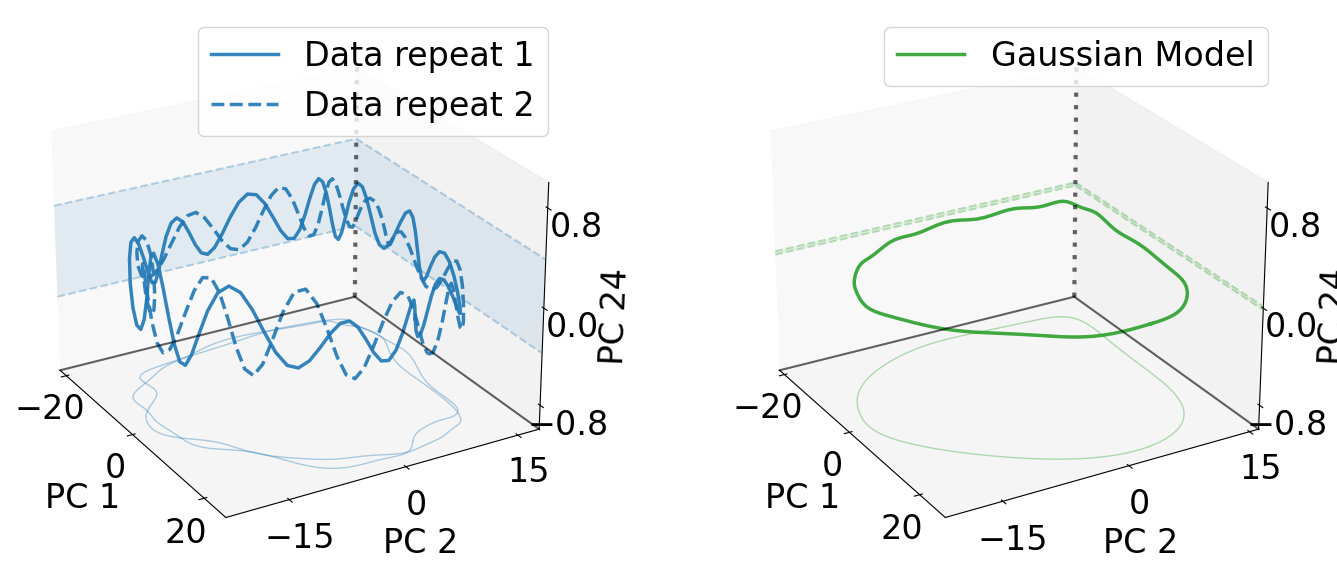

2 4


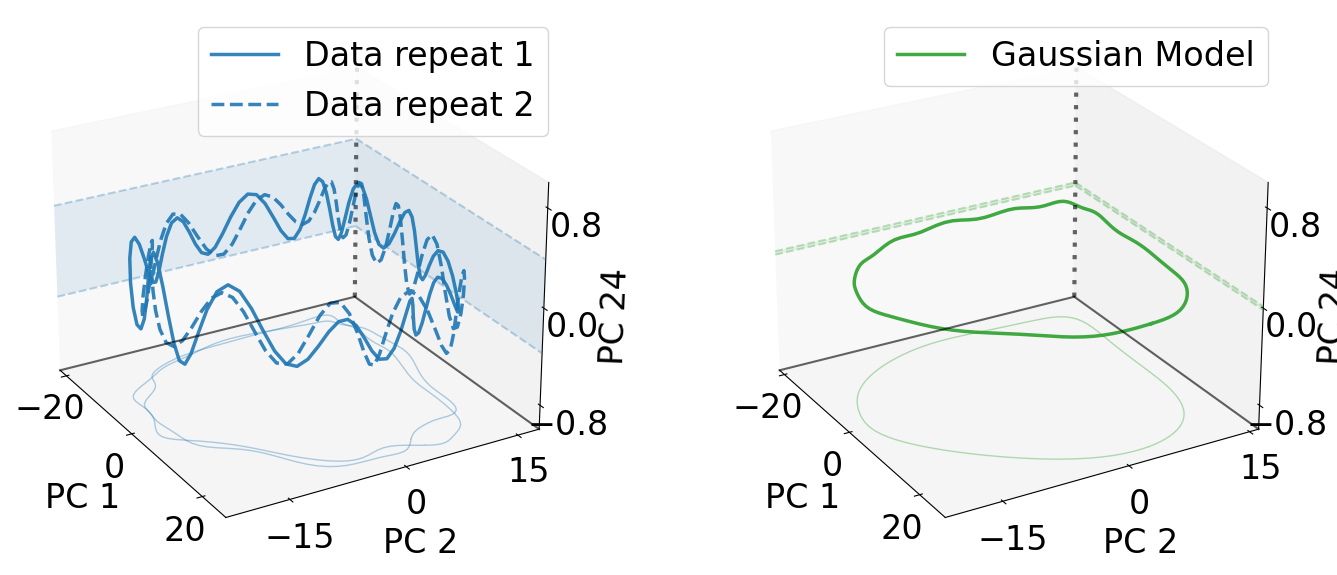

2 5


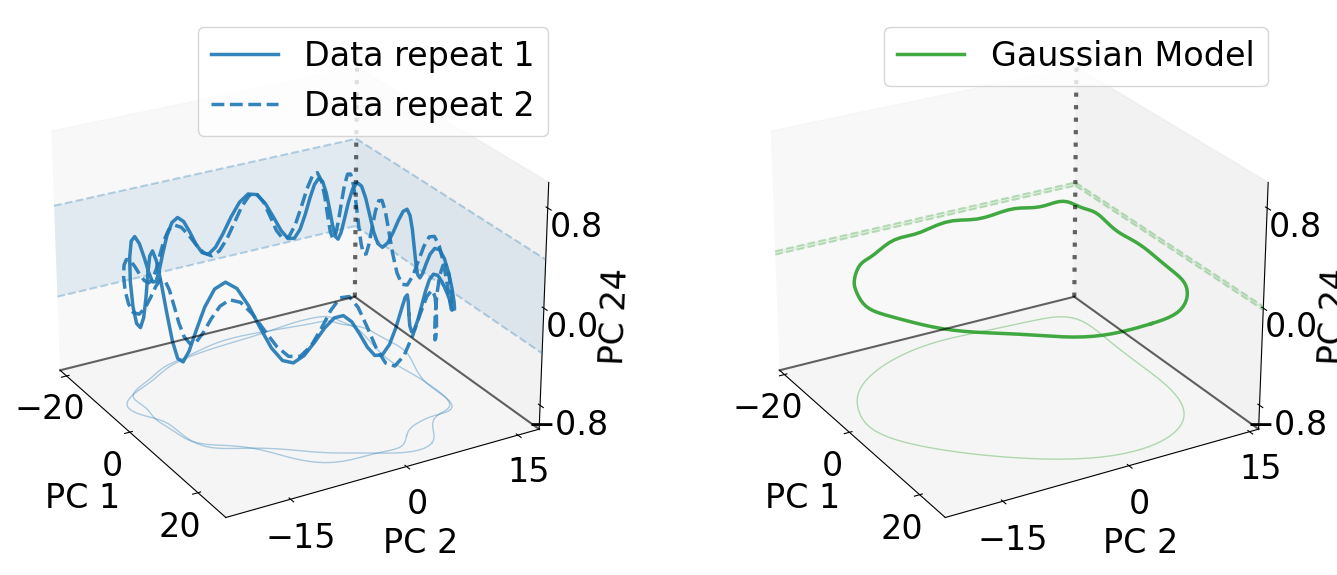

3 4


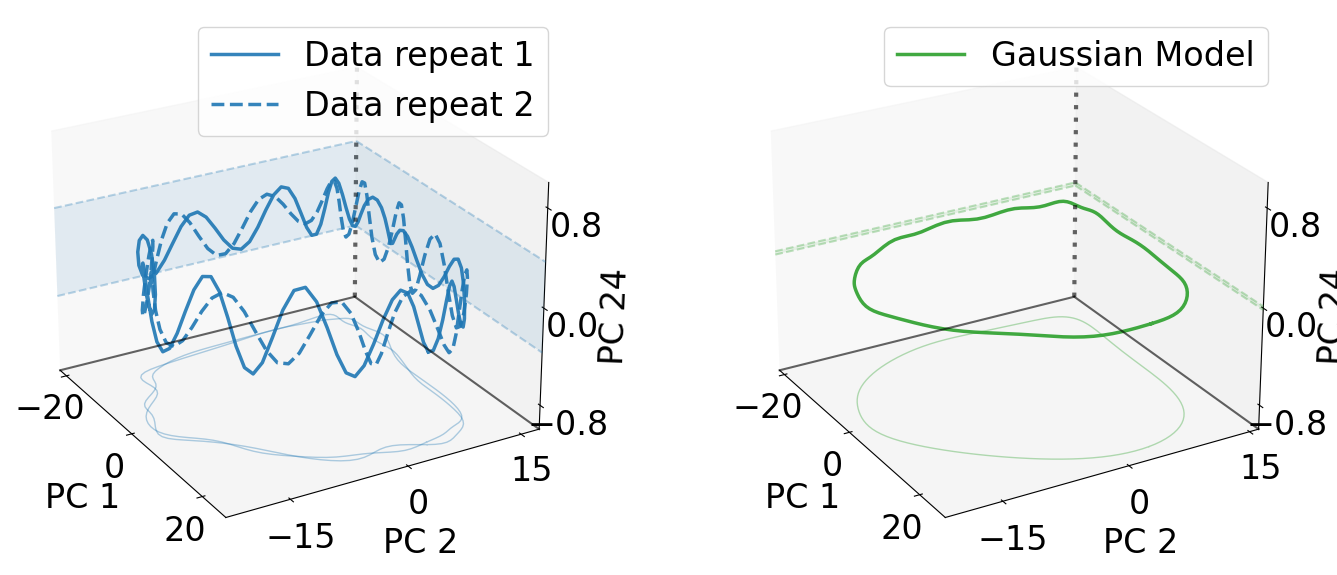

3 5


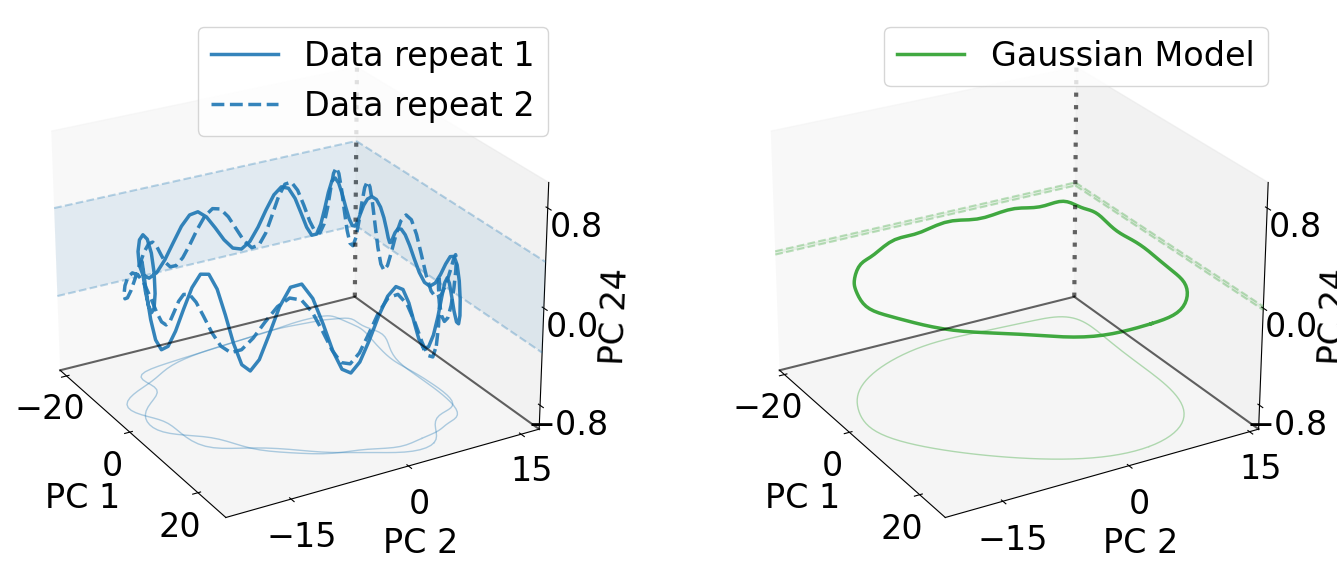

4 5


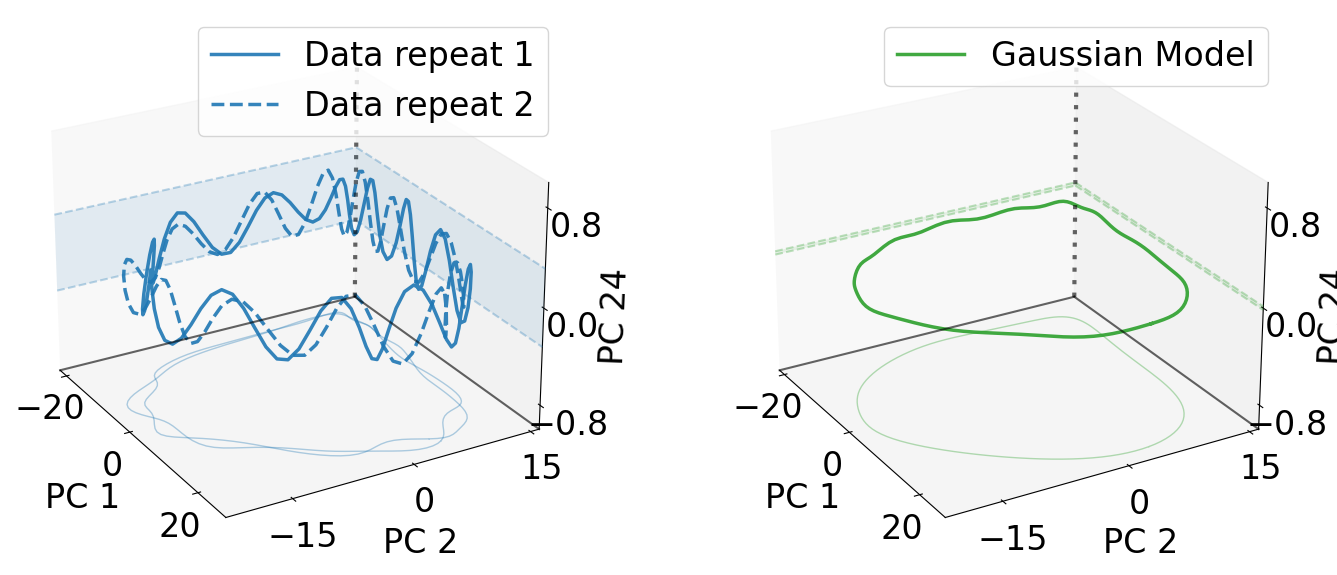

In [141]:
C = MP
for i in range(n_repeats_double):
    for j in range(i + 1, n_repeats_double):
        print(i, j)
        A, B = RP[i], RP[j]
        # get correlation between A[:, 2] and B[:, 2]. if negative, reflect B's z axis
        corr = np.corrcoef(A[:, 2], B[:, 2])[0, 1]
        if corr < 0:
            B[:, 2] = -B[:, 2]
        plot_point_clouds_3d_nested(
            # clouds=[[A, B], [C, GP]],
            clouds=[[A, B], [GP]],
            # colors=[['tab:blue', 'tab:blue'], ['tab:red', 'tab:green']],
            colors=[['tab:blue', 'tab:blue'], ['tab:green']],
            # labels=[['Data repeat 1', 'Data repeat 2'], ['AI Model','Gaussian Model']],
            labels=[['Data repeat 1', 'Data repeat 2'], ['Gaussian Model']],
            floor_dist=1,
            band_alpha=0.1,
            axis_alpha=0.6,
            title='',
            z_label=f'PC {z_dim}',
            figsize=(8, 6),
        )

# # reflect MP's y coordinates
# MP[:, 1] = -MP[:, 1]

# plot_point_clouds_3d(clouds=[RP[2], MP, GP],
#                      colors=['blue', 'red', 'green'],
#                      labels=['Response', 'Prediction', 'Gaussian Prediction'],
#                      floor_dist=1,
#                      band_alpha=0.1,
#                      axis_alpha=0.6,
#                      title=f'3D Projections',
#                      z_label=f'PC {z_dim}',
#                      figsize=(8, 6))

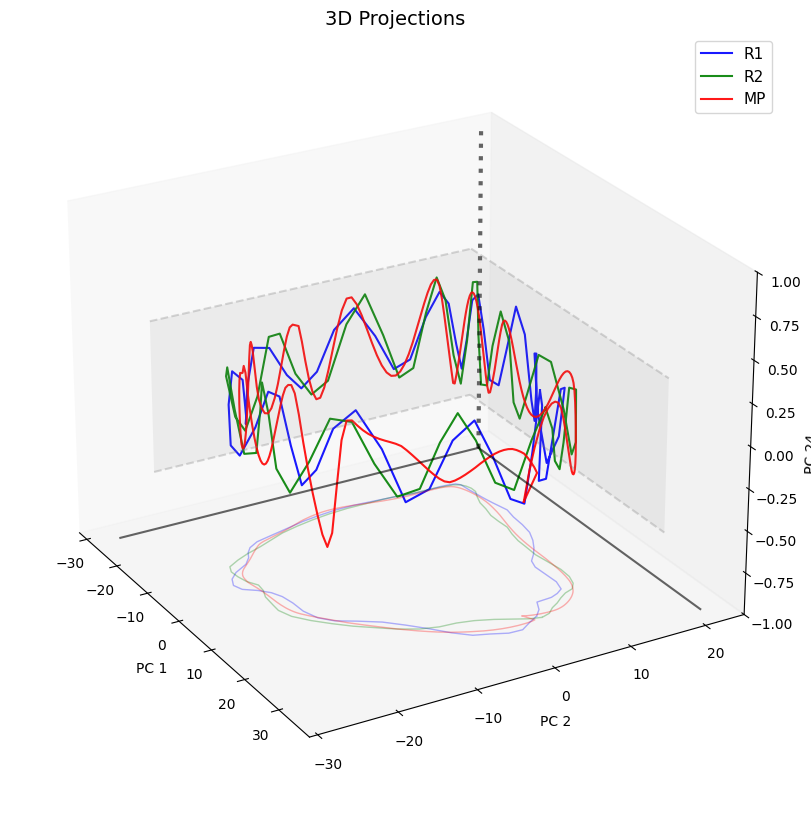

In [ ]:
plot_point_clouds_3d_onefig(clouds=[A, B, C],
                            colors=['blue', 'green', 'red'],
                            labels=['R1', 'R2', 'MP'],
                            floor_dist=1,
                            band_alpha=0.1,
                            axis_alpha=0.6,
                            title=f'3D Projections',
                            z_label=f'PC {z_dim}',
                            figsize=(8, 12))


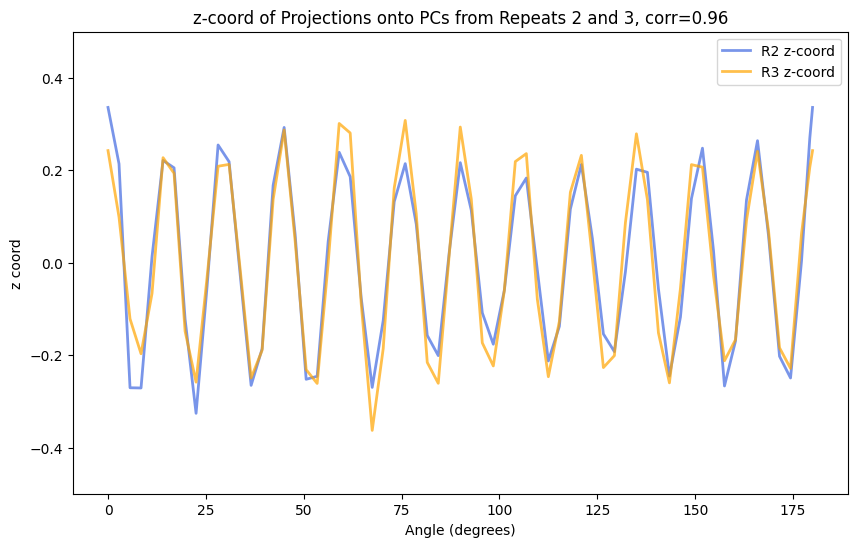

In [ ]:
# plot the z coord of R1P and R2P against angle
plt.figure(figsize=(10, 6))
# plt.plot(np.linspace(0, 180, n_orientations + 1), R1P[:, 2], label='R1 z-coord', color='green', linewidth=2, linestyle='-')
plt.plot(np.linspace(0, 180, n_angles + 1), RP[1, :, 2], label='R2 z-coord', color='royalblue', linewidth=2, linestyle='-', alpha =0.7)
plt.plot(np.linspace(0, 180, n_angles + 1), RP[2, :, 2], label='R3 z-coord', color='orange', linewidth=2, linestyle='-', alpha=0.7)
corr = np.corrcoef(RP[1, :, 2], RP[2, :, 2])[0, 1]
# plt.plot(np.linspace(0, 180, n_angles + 1), MP[:, 2], label='AI z-coord', color='red', linewidth=2, linestyle='-')
# plt.plot(np.linspace(0, 180, n_orientations + 1), GP[:, 2], label='Gaussian z-coord', color='orange', linewidth=2, linestyle='-')
plt.ylim(-0.5, 0.5)
plt.xlabel('Angle (degrees)')
plt.ylabel('z coord')
plt.title(f'z-coord of Projections onto PCs from Repeats 2 and 3, corr={corr:.2f}')
plt.legend()
plt.show()

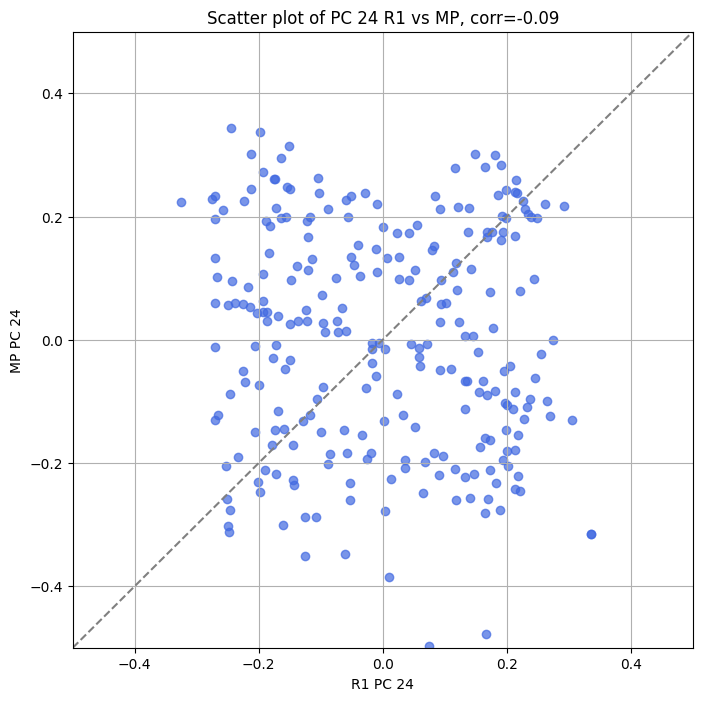

In [ ]:
# scatter plot of A against C z-coord
plt.figure(figsize=(8, 8))
plt.scatter(A[:, 2], C[:, 2], color='royalblue', alpha=0.7)
corr = np.corrcoef(A[:, 2], C[:, 2])[0, 1]
plt.xlabel(f'R1 PC {z_dim}')
plt.ylabel(f'MP PC {z_dim}')
plt.title(f'Scatter plot of PC {z_dim} R1 vs MP, corr={corr:.2f}')
# add a y=x line
plt.plot([-0.5, 0.5], [-0.5, 0.5], color='grey', linestyle='--')
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.grid()
plt.show()

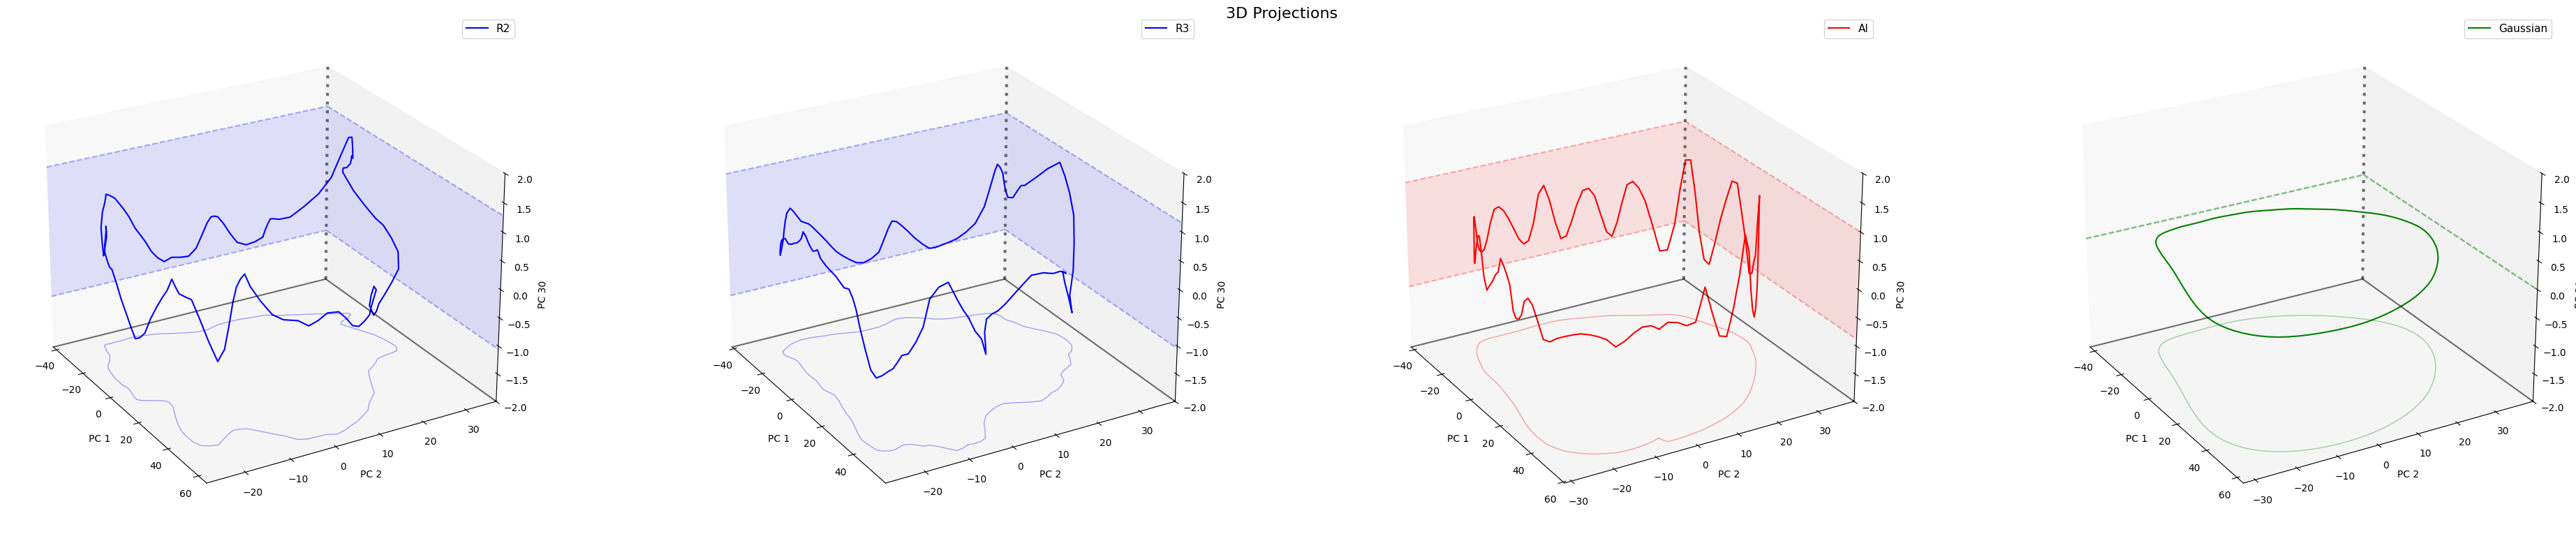

In [ ]:
z_dim = 30
# build projection matrices
P_data = U_data[0][:, [0,1, z_dim-1]]
P_pred = U_pred[:, [0,1, z_dim-1]]
P_pred_gauss = U_pred_gauss[:, [0,1, z_dim-1]]

# project into 3d
R1P = R_smooth_z[0].T @ P_data  # n_orientations x 3
R2P = R_smooth_z[1].T @ P_data  # n_orientations x 3
R3P = R_smooth_z[2].T @ P_data  # n_orientations x 3
R23 = (R_smooth_z[1] + R_smooth_z[2])/(np.sqrt(2))
R23P = R23.T @ P_data
# R1P = R_z[0].T @ P_data 
# R2P = R_z[1].T @ P_data 
# R3P = R_z[2].T @ P_data 

# R2P_shuffles = np.zeros((n_shuffles, n_orientations, 3))
# R3P_shuffles = np.zeros((n_shuffles, n_orientations, 3)) 
# for i in range(n_shuffles):
#     P_data = U_data[i][:, [0, 1, z_dim - 1]]
#     R2P_shuffles[i] = R_smooth_z[i, 1].T @ P_data
#     R3P_shuffles[i] = R_smooth_z[i, 2].T @ P_data
# R2P = R2P_shuffles.mean(axis=0)
# R3P = R3P_shuffles.mean(axis=0)

MP = pred_z.T @ P_pred  # n_orientations x 3
# MP = pred_z.T @ P_data
GP = pred_gauss_z.T @ P_pred_gauss  # n_orientations x 3
# GP = pred_gauss_z.T @ P_data  # n_orientations x 3
R1P = np.vstack([R1P, R1P[0]])
R2P = np.vstack([R2P, R2P[0]])
R3P = np.vstack([R3P, R3P[0]])
MP = np.vstack([MP, MP[0]])
GP = np.vstack([GP, GP[0]])

plot_point_clouds_3d(
clouds=[R2P, R3P, MP, GP],
colors=['blue', 'blue', 'red', 'green'],
labels=['R2', 'R3', 'AI', 'Gaussian'],
# clouds=[R1P, R2P, R3P, MP, GP],
# colors=['blue', 'blue', 'blue', 'red', 'green'],
# labels=['R1', 'R2', 'R3', 'AI', 'Gaussian'],
# clouds=[R23P, MP, GP],
# colors=['blue', 'red', 'green'],
# labels=['R2+R3', 'AI', 'Gaussian'],
title='3D Projections',
z_label=f'PC {z_dim}',
floor_dist=2,
figsize=(10, 8),
)

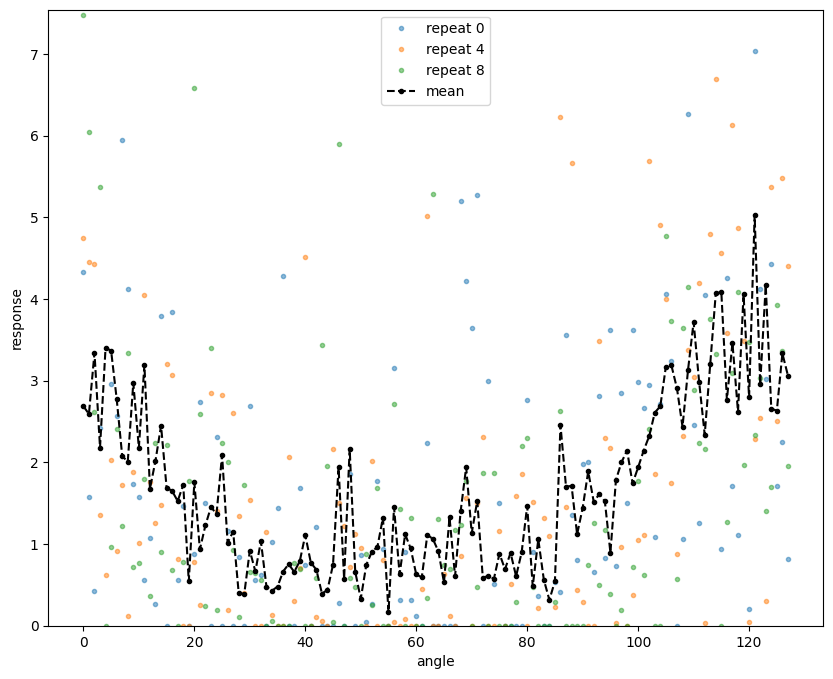

In [ ]:
cell_no = np.random.randint(n_cells)
plt.figure(figsize=(10,8))
for i in range(0, n_repeats * downsample_factor, 4):
    plt.plot(R_double[i, cell_no], label=f'repeat {i}', linestyle='none', marker='o', markersize=3, alpha=0.5)
# plot the mean
plt.plot(R_double_mean[cell_no], label='mean', linestyle='--', marker='o', markersize=3, color='k')
plt.xlabel('angle')
plt.ylabel('response')
plt.ylim(0, np.max(R_double_mean[cell_no]) * 1.5)
plt.legend()
plt.show()

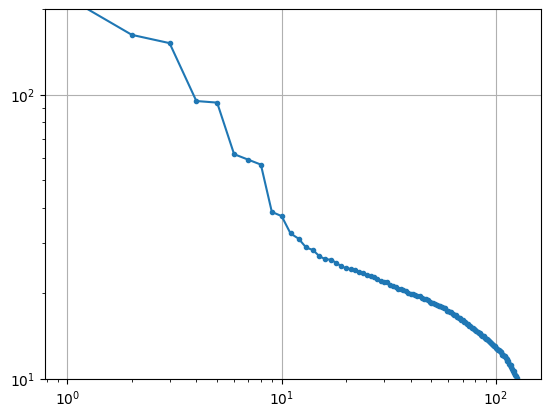

In [ ]:
R_double_mean_z = (R_double_mean - R_double_mean.mean(axis=-1, keepdims=True)) / R_double_mean.std(axis=-1, keepdims=True)
U, lam = np.linalg.svd(R_double_mean_z, full_matrices=False)[:2]
plt.plot(lam, markersize=3, marker='o')
plt.grid()
# plt.xlim(0, 50)
plt.ylim(10, 2 * 1e2)
plt.xscale('log')
plt.yscale('log')
plt.show()

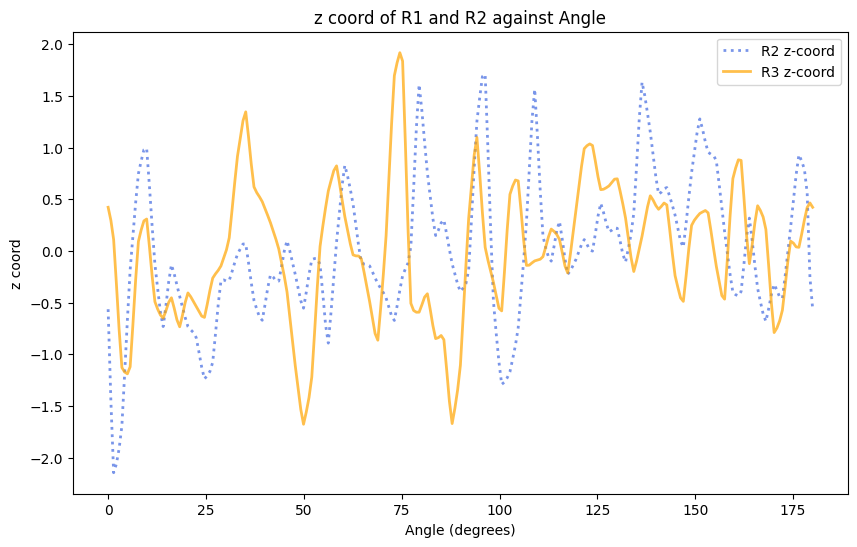

In [ ]:
# plot the z coord of R1P and R2P against angle
plt.figure(figsize=(10, 6))
# plt.plot(np.linspace(0, 180, n_orientations + 1), R1P[:, 2], label='R1 z-coord', color='green', linewidth=2, linestyle='-')
plt.plot(np.linspace(0, 180, n_orientations + 1), R2P[:, 2], label='R2 z-coord', color='royalblue', linewidth=2, linestyle=':', alpha =0.7)
plt.plot(np.linspace(0, 180, n_orientations + 1), R3P[:, 2], label='R3 z-coord', color='orange', linewidth=2, linestyle='-', alpha=0.7)
# plt.plot(np.linspace(0, 180, n_orientations + 1), MP[:, 2], label='AI z-coord', color='red', linewidth=2, linestyle='-')
# plt.plot(np.linspace(0, 180, n_orientations + 1), GP[:, 2], label='Gaussian z-coord', color='orange', linewidth=2, linestyle='-')
plt.xlabel('Angle (degrees)')
plt.ylabel('z coord')
plt.title('z coord of R1 and R2 against Angle')
plt.legend()
plt.show()

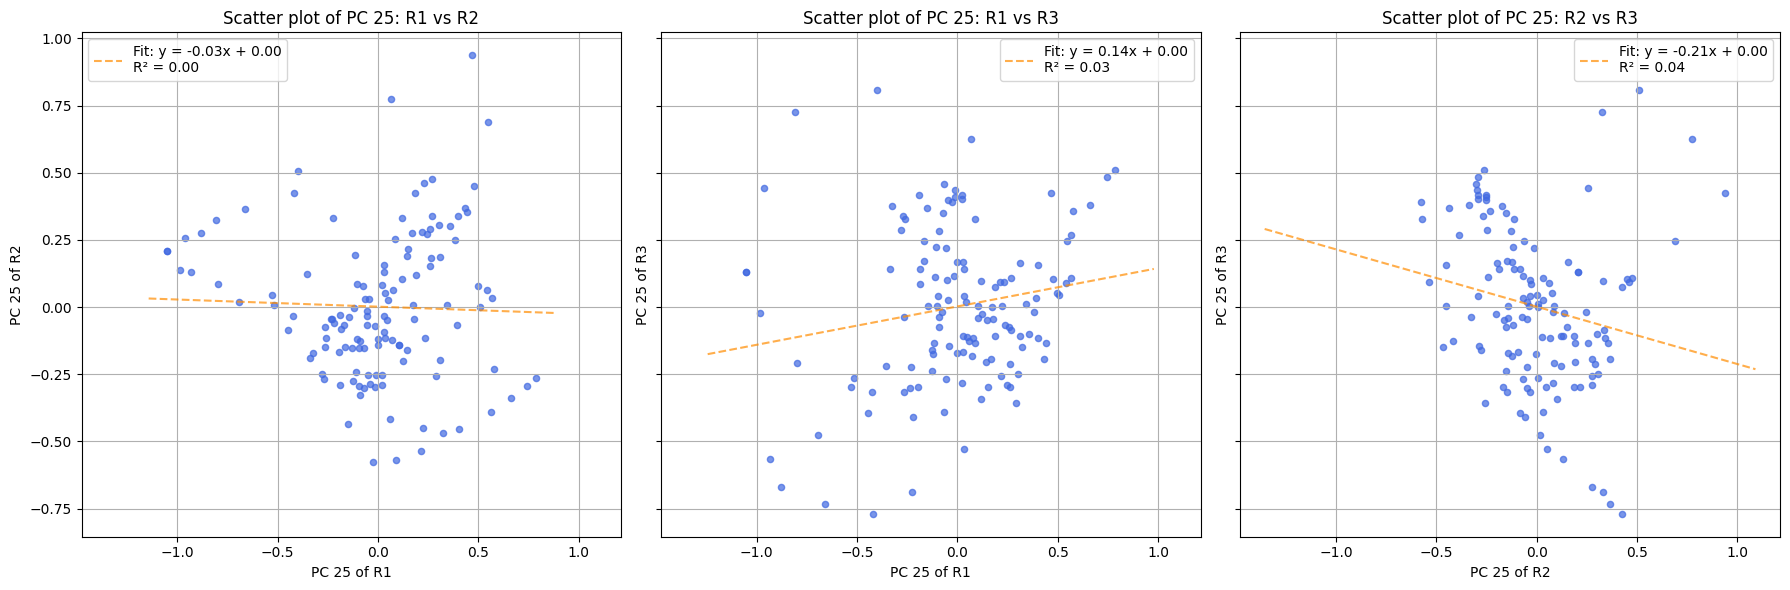

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Define the pairs
pairs = [
    (R1P[:, 2], R2P[:, 2], 'R1', 'R2'),
    (R1P[:, 2], R3P[:, 2], 'R1', 'R3'),
    (R2P[:, 2], R3P[:, 2], 'R2', 'R3')
]

for ax, (x, y, label_x, label_y) in zip(axes, pairs):
    ax.scatter(x, y, color='royalblue', alpha=0.7, s=20)
    # Fit line of best fit
    m, b = np.polyfit(x, y, 1)
    r_squared = np.corrcoef(x, y)[0, 1]**2
    x_vals = np.array(ax.get_xlim())
    y_vals = m * x_vals + b
    ax.plot(x_vals, y_vals, color='darkorange', linestyle='--', alpha=0.7,
            label=f'Fit: y = {m:.2f}x + {b:.2f}\nR² = {r_squared:.2f}')
    ax.legend()
    ax.set_xlabel(f'PC {z_dim} of {label_x}')
    ax.set_ylabel(f'PC {z_dim} of {label_y}')
    ax.set_title(f'Scatter plot of PC {z_dim}: {label_x} vs {label_y}')
    ax.grid()

plt.tight_layout()
plt.show()

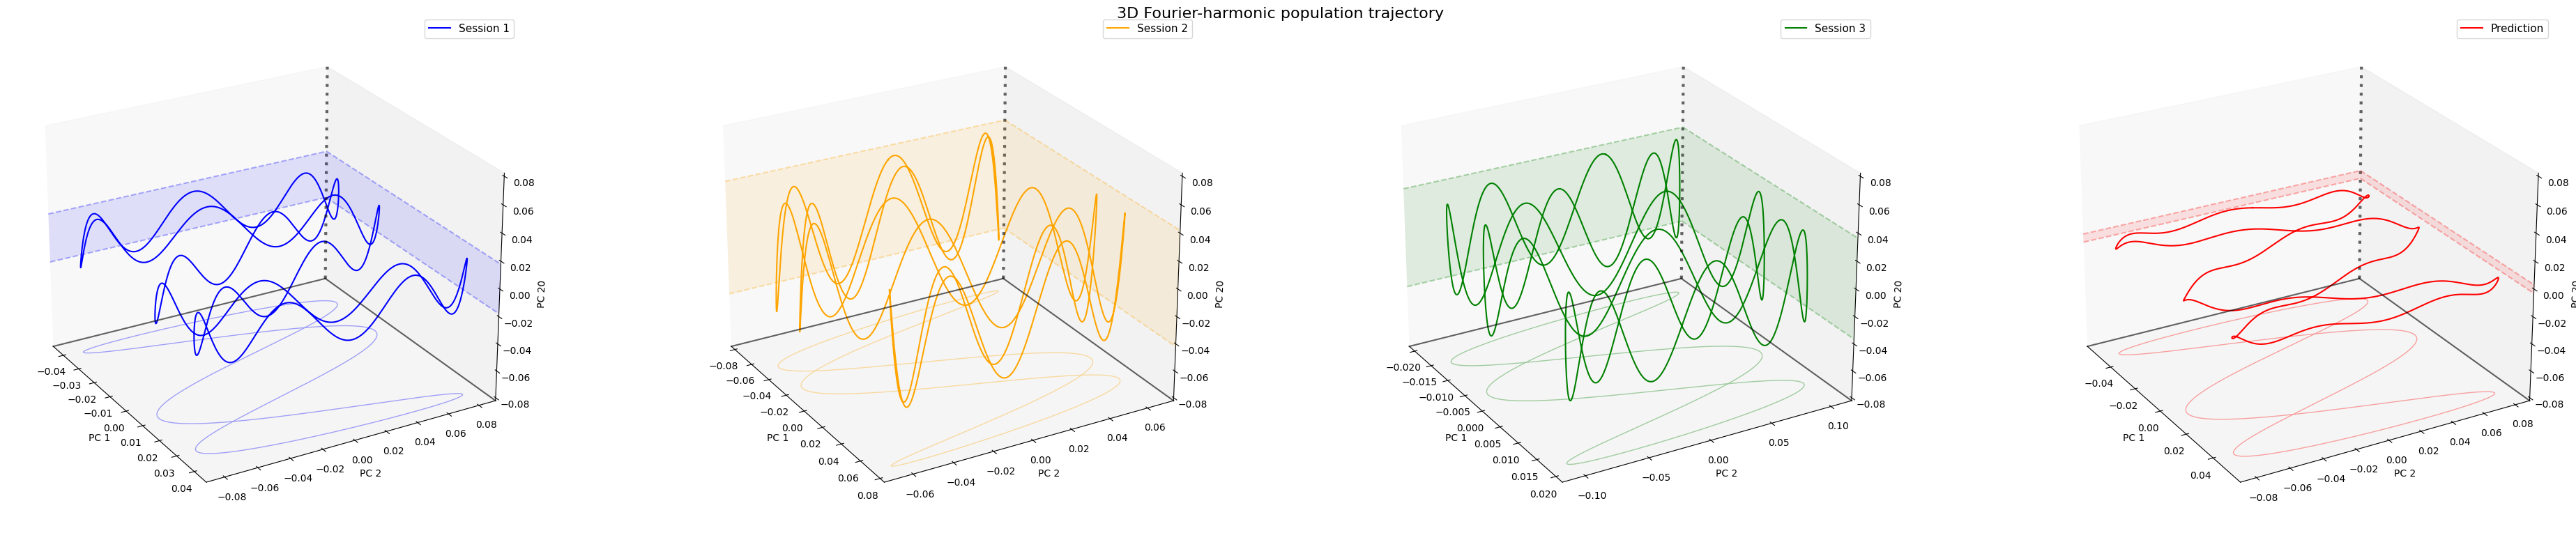

In [ ]:
# z_dim = 20
# def fourier_design(angles):
#     """Return (n_stim, 2H) with [sinθ, cosθ, sin2θ, cos2θ, ..., sinHθ, cosHθ] and L2-normalized columns."""
#     cols = []
#     for h in [1, 3, z_dim-1]:  # harmonics to include
#         cols.append(np.sin(h*angles))
#         cols.append(np.cos(h*angles))
#     Phi = np.column_stack(cols)
#     # column-normalize on the discrete grid
#     Phi = Phi / np.linalg.norm(Phi, axis=0, keepdims=True)
#     return Phi  # n_stim x (2H)

# def population_fourier_curve(R, angles, agg='mean'):
#     """
#     R: (n_cells, n_stim) for one session (z-scored per cell if you like).
#     Returns an (n_stim, 3) trajectory using harmonics 1,2,3 for x,y,z.
#     """
#     Phi = fourier_design(angles)                    # n_stim x (2H)
#     # least-squares coefficients per cell (n_cells x 2H); ΦᵀΦ is identity if columns normalized+orthogonal
#     G = np.linalg.pinv(Phi)                              # (2H x n_stim)
#     B = R @ G.T                                          # n_cells x (2H)

#     # aggregate across cells -> population coefficients
#     a = B.mean(axis=0) if agg == 'mean' else B.sum(axis=0)   # length 2H

#     # build the 3D curve
#     s1, c1, s2, c2, s3, c3 = [Phi[:, i] for i in range(6)]
#     X = a[0]*s1 + a[1]*c1
#     Y = a[2]*s2 + a[3]*c2
#     Z = a[4]*s3 + a[5]*c3
#     curve = np.column_stack([X, Y, Z])                 # (n_stim, 3)

#     # close the loop for plotting
#     curve = np.vstack([curve, curve[0]])
#     return curve

# R_smooth_z = (R_smooth - np.mean(R_smooth, axis=-1, keepdims=True)) / (np.std(R_smooth, axis=-1, keepdims=True) + 1e-10)
# pred_z = (pred - np.mean(pred, axis=-1, keepdims=True)) / (np.std(pred, axis=-1, keepdims=True) + 1e-10)

# # Example for your four sessions:
# R1P = population_fourier_curve(R_smooth_z[0], angles, agg='mean')
# R2P = population_fourier_curve(R_smooth_z[1], angles, agg='mean')
# R3P = population_fourier_curve(R_smooth_z[2], angles, agg='mean')
# PredP = population_fourier_curve(pred_z, angles, agg='mean')

# plot_point_clouds_3d(
#     clouds=[R1P, R2P, R3P, PredP],
#     colors=['blue', 'orange', 'green', 'red'],
#     labels=['Session 1', 'Session 2', 'Session 3', 'Prediction'],
#     floor_dist=0.8*np.max(np.abs(np.vstack([R1P,R2P,R3P,PredP]))),
#     band_alpha=0.1, axis_alpha=0.6,
#     title='3D Fourier-harmonic population trajectory',
#     z_label=f'PC {z_dim}',
#     figsize=(10,8)
# )


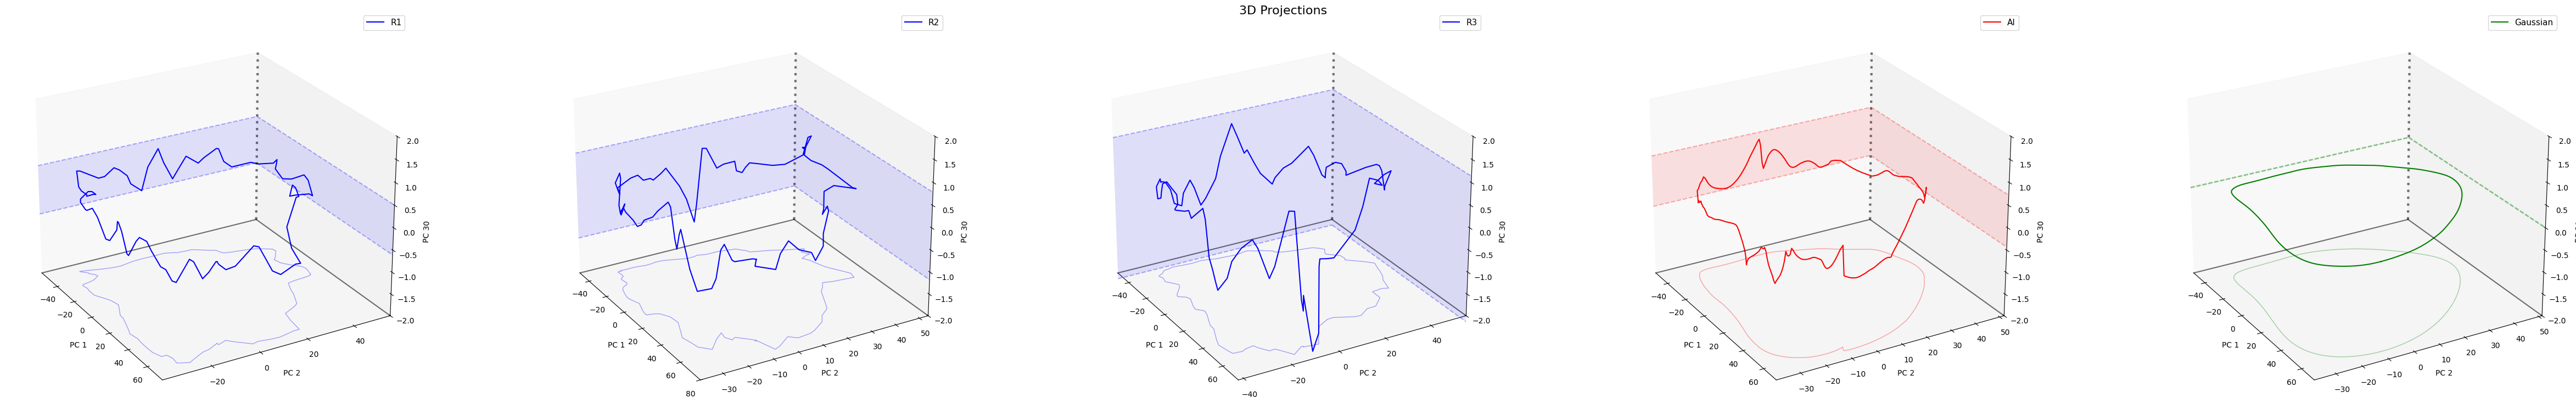

In [ ]:
z_dim = 30
downsample_factor = 1
# R_cropped = R[:, :, :n_angles - n_angles % downsample_factor]
R_binned = R_smooth.reshape(n_repeats, n_cells, n_angles // downsample_factor, downsample_factor).mean(axis=-1)
pred_binned = pred.reshape(n_cells, n_angles // downsample_factor, downsample_factor).mean(axis=-1)
pred_gauss_binned = pred_gauss.reshape(n_cells, n_angles // downsample_factor, downsample_factor).mean(axis=-1)

# average with angle + pi
n_orientations = R_binned.shape[2] // 2
R_binned = (R_binned[:, :, :n_orientations] + R_binned[:, :, n_orientations:]) / 2
pred_binned = (pred_binned[:, :n_orientations] + pred_binned[:, n_orientations:]) / 2
pred_gauss_binned = (pred_gauss_binned[:, :n_orientations] + pred_gauss_binned[:, n_orientations:]) / 2
R_binned_mean = R_binned.mean(axis=0)
# z-score
R_binned = R_binned - R_binned.mean(axis=-1, keepdims=True)
pred_binned = pred_binned - pred_binned.mean(axis=-1, keepdims=True)
pred_gauss_binned = pred_gauss_binned - pred_gauss_binned.mean(axis=-1, keepdims=True)
R_binned_mean = R_binned_mean - R_binned_mean.mean(axis=-1, keepdims=True)

# h = 1e-3
# cursed_hybrid = h * R_binned_mean + (1 - h) * pred_gauss_binned
# cursed_hybrid = (cursed_hybrid - cursed_hybrid.mean(axis=-1, keepdims=True)) / (cursed_hybrid.std(axis=-1, keepdims=True, ddof=0) + 1e-10)
# U = np.linalg.svd(R_binned_mean, full_matrices=False)[0] # n_cells x n_orientations
U = np.linalg.svd(pred_gauss_binned, full_matrices=False)[0]
# U = np.linalg.svd(cursed_hybrid, full_matrices=False)[0]
# P = U[:, [0, 1, z_dim-1]]  # n_cells x 3
P = U[:, [0, 1, z_dim-1]]  # n_cells x 3
# project into 3d
R1P = R_binned[0].T @ P  # n_orientations x 3
R2P = R_binned[1].T @ P  # n_orientations x 3
R3P = R_binned[2].T @ P  # n_orientations x 3
MP = pred_binned.T @ P  # n_orientations x 3
GP = pred_gauss_binned.T @ P  # n_orientations x 3
R1P = np.vstack([R1P, R1P[0]])
R2P = np.vstack([R2P, R2P[0]])
R3P = np.vstack([R3P, R3P[0]])
MP = np.vstack([MP, MP[0]])
GP = np.vstack([GP, GP[0]])

plot_point_clouds_3d(
    clouds=[R1P, R2P, R3P, MP, GP],
    colors=['blue', 'blue', 'blue', 'red', 'green'],
    labels=['R1', 'R2', 'R3', 'AI', 'Gaussian'],
    title='3D Projections',
    z_label=f'PC {z_dim}',
    floor_dist=2,
    figsize=(10, 8),
)

# plot_point_clouds_3d(
#     clouds=[R1P, R2P, MP],
#     colors=['blue', 'orange', 'red'],
#     labels=['R1', 'R2', 'AI'],
#     title='3D Projections of Responses',
#     z_label=f'PC {z_dim}',
#     floor_dist=5,
#     figsize=(10, 8)
# )

# plot_point_clouds_3d(
#     clouds=[R1P, R2P, GP],
#     colors=['blue', 'orange', 'green'],
#     labels=['R1', 'R2', 'Gaussian'],
#     title='3D Projections of Responses',
#     z_label=f'PC {z_dim}',
#     floor_dist=5,
#     figsize=(10, 8)
# )

# plot_point_clouds_3d(
#     clouds= [MP, GP],
#     colors=['blue', 'orange'],
#     labels=['AI', 'Gaussian'],
#     title='3D Projections of Responses',
#     z_label=f'PC {z_dim}',
#     floor_dist=4,
#     figsize=(10, 8)
# )

# plot_point_clouds_3d(
#     clouds=[R1P, R2P, R3P],
#     colors=['blue', 'orange', 'green'],
#     labels=['R1', 'R2', 'R3'],
#     title='3D Projections of Responses',
#     z_label=f'PC {z_dim}',
#     floor_dist=5,
#     figsize=(10, 8)
# )

# plot_point_clouds_3d_onefig(
#     clouds=[R1P, R2P],
#     colors=['blue', 'orange'],
#     labels=['R1', 'R2'],
#     title='3D Projections of Responses',
#     z_label=f'PC {z_dim}',
#     floor_dist=8,
#     figsize=(10, 8)
# )

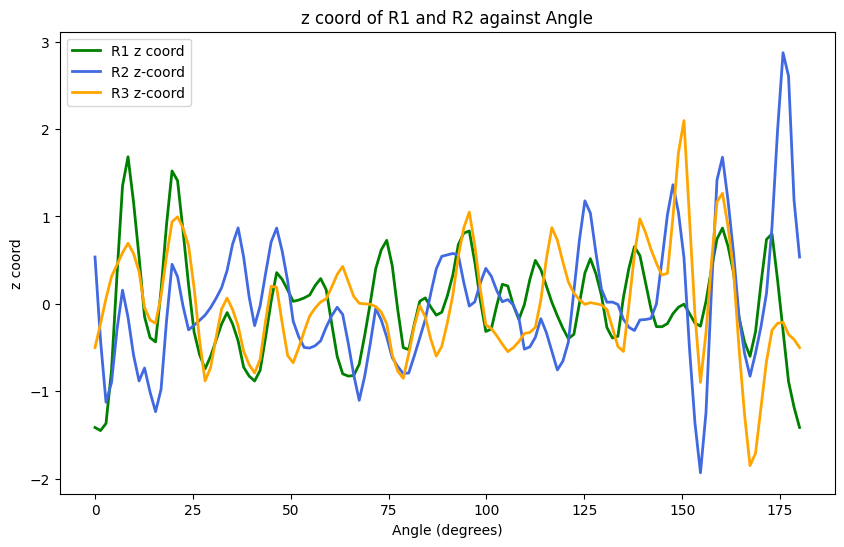

In [ ]:
# plot the z coord of R1P and R2P against angle
plt.figure(figsize=(10, 6))
plt.plot(np.linspace(0, 180, n_orientations + 1), R1P[:, 2], label='R1 z coord', color='green', linewidth=2)
plt.plot(np.linspace(0, 180, n_orientations + 1), R2P[:, 2], label='R2 z-coord', color='royalblue', linewidth=2, linestyle='-')
plt.plot(np.linspace(0, 180, n_orientations + 1), R3P[:, 2], label='R3 z-coord', color='orange', linewidth=2, linestyle='-')
# plt.plot(np.linspace(0, 180, n_orientations + 1), MP[:, 2], label='AI z-coord', color='blue', linewidth=2, linestyle='-')
# plt.plot(np.linspace(0, 180, n_orientations + 1), GP[:, 2], label='Gaussian z-coord', color='orange', linewidth=2, linestyle='-')
plt.xlabel('Angle (degrees)')
plt.ylabel('z coord')
plt.title('z coord of R1 and R2 against Angle')
plt.legend()
plt.show()

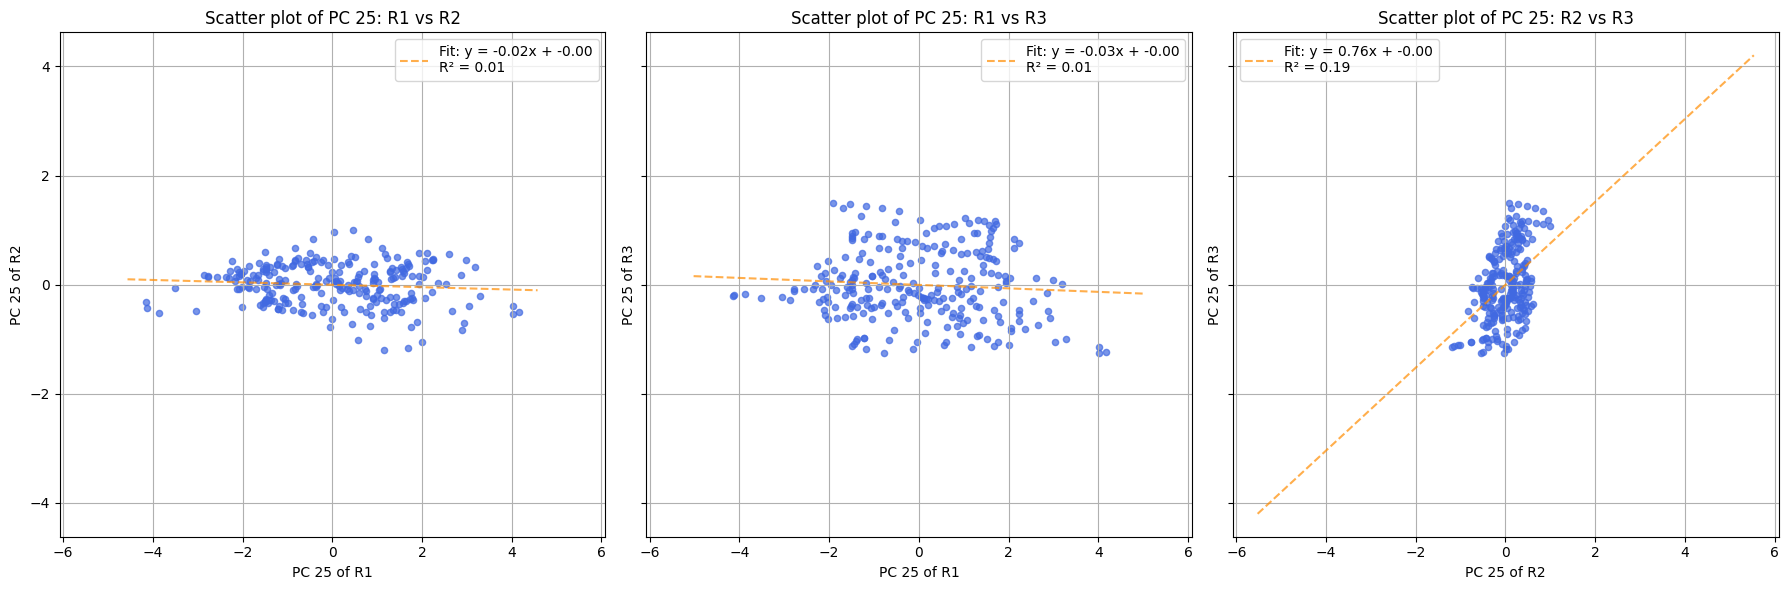

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Define the pairs
pairs = [
    (R1P[:, 2], R2P[:, 2], 'R1', 'R2'),
    (R1P[:, 2], R3P[:, 2], 'R1', 'R3'),
    (R2P[:, 2], R3P[:, 2], 'R2', 'R3')
]

for ax, (x, y, label_x, label_y) in zip(axes, pairs):
    ax.scatter(x, y, color='royalblue', alpha=0.7, s=20)
    # Fit line of best fit
    m, b = np.polyfit(x, y, 1)
    r_squared = np.corrcoef(x, y)[0, 1]**2
    x_vals = np.array(ax.get_xlim())
    y_vals = m * x_vals + b
    ax.plot(x_vals, y_vals, color='darkorange', linestyle='--', alpha=0.7,
            label=f'Fit: y = {m:.2f}x + {b:.2f}\nR² = {r_squared:.2f}')
    ax.legend()
    ax.set_xlabel(f'PC {z_dim} of {label_x}')
    ax.set_ylabel(f'PC {z_dim} of {label_y}')
    ax.set_title(f'Scatter plot of PC {z_dim}: {label_x} vs {label_y}')
    ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
# downsample_factor = 2
# pred_down = pred.reshape(n_cells, n_angles // downsample_factor, downsample_factor).mean(axis=2)
# pred_gauss_down = pred_gauss.reshape(n_cells, n_angles // downsample_factor, downsample_factor).mean(axis=2)

# evals_model = np.array(vanilla_cvpca(pred_down, pred_down))
# evals_model_gauss = np.array(vanilla_cvpca(pred_gauss, pred_gauss))
# evals_est = np.array(sym_cvpca(R_down, R_down_smooth))

# # normalize to have same sum
# evals_model /= evals_model.sum()
# evals_model_gauss /= evals_model_gauss.sum()
# evals_est /= evals_est.sum()

In [ ]:
# # for each cell, find the most common best frac value across sessions
# def mode(lst):
#     return max(set(lst), key=lst.count)
# best_frac_mode = np.array([mode(best_fracs[i].tolist()) for i in range(n_cells)])

In [ ]:
# n_shuffles = 8
# evals_shuffled = np.zeros((n_shuffles, n_angles//2))
# for s in tqdm(range(n_shuffles), desc="Shuffling and computing cvPCA"):
#     R_down_shuffled = np.zeros_like(R_down)
#     R_down_shuffled_smooth = np.zeros_like(R_down)
#     # shuffle the repeats order of each stimulus independently
#     for theta in range(n_angles // 2):
#         perm = np.random.permutation(2 * n_repeats)
#         R_down_shuffled[:, :, theta] = R_down[perm, :, theta]
#     # smooth all sessions with the mode frac
#     for r in range(R_down.shape[0]):
#         for c in range(n_cells):
#             mean_est = sm.nonparametric.lowess(R_down_shuffled[r, c], angles_down,
#                                         frac=best_frac_mode[c], it=0, delta=0.05,
#                                         return_sorted=True)
#             R_down_shuffled_smooth[r, c] = mean_est[:, 1]
#         print(f"session {s +1}, repeat {r + 1} smoothing done")
#     # compute evals
#     evals_shuffled[s] = sym_cvpca(R_down_shuffled, R_down_shuffled_smooth)

In [ ]:
# evals_est = evals_shuffled.mean(axis=0)
# evals_scv_pooled = np.zeros_like(evals_est) * np.nan
# # evals_cv_pooled = np.zeros_like(evals_raw) * np.nan
# # after 16 components, average adjacent components to reduce noise
# # we will choose pool sizes increasing
# start = 10
# evals_scv_pooled[:start] = evals_est[:start]
# # evals_cv_pooled[:start] = evals_raw[:start]
# edges = [start]
# while edges[-1] < len(evals_est):
#     next_edge = int(edges[-1] * 1.25)
#     if next_edge < len(evals_est):
#         print(f"Pooling components {edges[-1]} to {next_edge - 1}")
#         edges.append(next_edge)
#         evals_scv_pooled[edges[-2]] = np.mean(evals_est[edges[-2]:next_edge])
#         # evals_cv_pooled[edges[-2]] = np.mean(evals_raw[edges[-2]:next_edge])
#     else:
#         print(f"Pooling components {edges[-1]} to {len(evals_est) - 1}")
#         evals_scv_pooled[edges[-1]] = np.mean(evals_est[edges[-1]:])
#         # evals_cv_pooled[edges[-1]] = np.mean(evals_raw[edges[-1]:])
#         edges.append(len(evals_est))
#         break
# edges = np.array(edges) + 1

In [ ]:
# R_z = (R - R.mean(axis=1, keepdims=True)) / (R.std(axis=1, keepdims=True, ddof=0) + 1e-10) # 3 x n_cells x n_angles
# C_sym = np.zeros((n_angles, n_angles))
# counter = 0
# for i in range(n_repeats):
#     for j in range(n_repeats):
#         if i >= j:
#             continue
#         C_sym += R_z[i].T @ R_z[j] / n_cells
#         counter += 1
#         print(f"C_{i}{j} variance {np.trace(R_z[i].T @ R_z[j] / n_cells)}")
# C_sym /= counter
# print(f"averaged cross-covariance matrix over {counter} pairs of repeats")
# pred_z = (pred - pred.mean(axis=0, keepdims=True)) / (pred.std(axis=0, keepdims=True, ddof=0) + 1e-10) # n_cells x n_angles
# c_model = pred_z.T @ pred_z / n_cells
# print(f"data variance {np.trace(C_sym)}, model variance {np.trace(c_model)}")


C_01 variance 350.078857421875
C_02 variance 351.6233825683594
C_12 variance 337.013427734375
averaged cross-covariance matrix over 3 pairs of repeats
data variance 346.2385559479395, model variance 1024.0


In [ ]:
# R_mean = R.mean(axis=0)
# R_mean_z = (R_mean - R_mean.mean(axis=0, keepdims=True)) / (R_mean.std(axis=0, keepdims=True, ddof=0) + 1e-10)
# C_data = R_mean_z.T @ R_mean_z / n_cells # n_stim x n_stim
# pred_z = (pred - pred.mean(axis=1, keepdims=True)) / (pred.std(axis=1, keepdims=True) + 1e-10)
# C_model = pred_z.T @ pred_z / n_cells # n_stim x n_stim
# print(f"data variance {np.trace(C_data)}, pred variance {np.trace(C_model)}")

data variance 1024.0, pred variance 1024.0


In [ ]:
np.sum(evals_model) / np.sum(evals_est)

np.float64(2.960062114818673)

In [ ]:
def covariance_to_kernel(C):
    """
    Estimate kernel K(dtheta) from covariance matrix C_ij
    by averaging across diagonals (with wrap-around).
    
    Parameters
    ----------
    C : ndarray (n, n)
        Covariance matrix indexed by angle.
    
    Returns
    -------
    K : ndarray (n,)
        Kernel function sampled at discrete angular differences.
    """
    n = C.shape[0]
    K = np.zeros(n)

    for shift in range(n):
        # take diagonal with periodic wrap-around
        vals = [C[i, (i + shift) % n] for i in range(n)]
        K[shift] = np.mean(vals)
    
    return K

In [ ]:
C = np.zeros((n_angles, n_angles))
Rz = np.zeros_like(R)
pred_z = (pred - pred.mean(axis=0, keepdims=True)) / pred.std(axis=0, keepdims=True)
C_model = pred_z.T @ pred_z / n_cells
for i in range(n_repeats):
    Rz[i] = (R[i] - R[i].mean(axis=0, keepdims=True)) / R[i].std(axis=0, keepdims=True)
for i, j in np.ndindex(n_repeats, n_repeats):
    if i == j:
        continue
    C += Rz[i].T @ Rz[j] / (6 * n_cells)
K = covariance_to_kernel(C)
K_model = covariance_to_kernel(C_model)
K_shifted = np.fft.fftshift(K)
K_model_shifted = np.fft.fftshift(K_model)

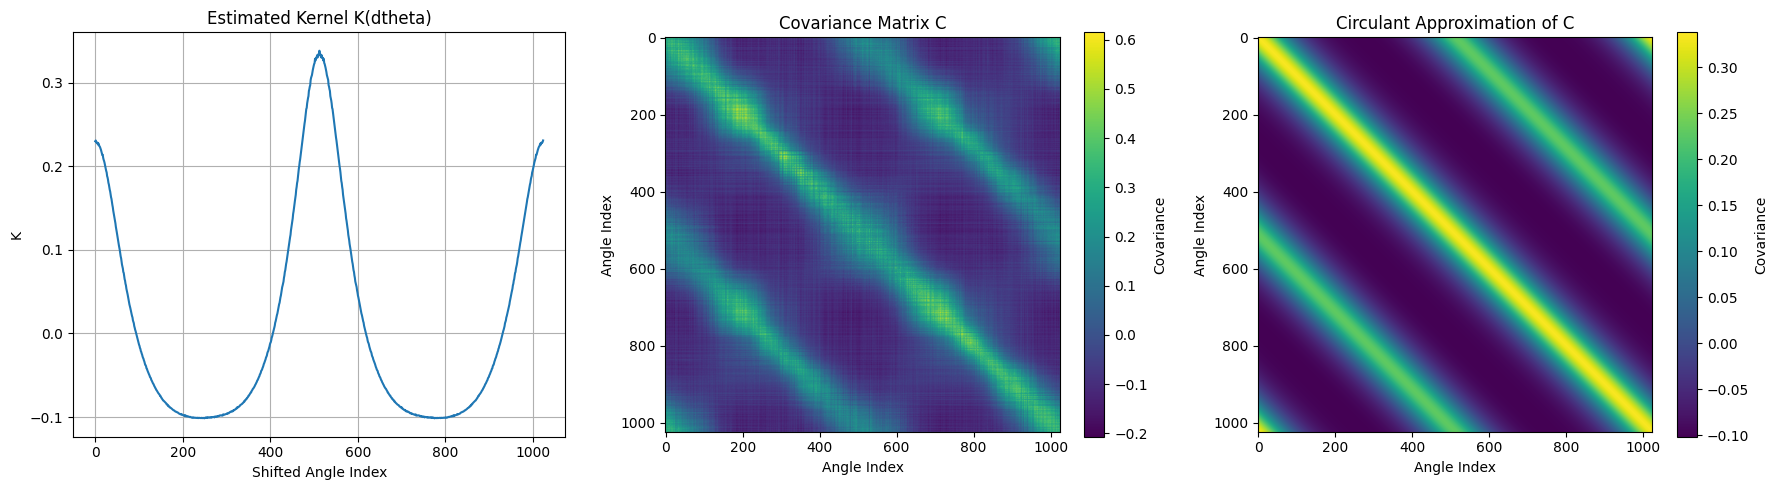

In [ ]:
plt.figure(figsize=(18, 5))
plt.subplot(131)
plt.plot(np.fft.fftshift(K), label='data')
plt.title('Estimated Kernel K(dtheta)')
plt.xlabel('Shifted Angle Index')
plt.ylabel('K')
plt.grid()
# plt.xlim(n_angles // 2 -250, n_angles // 2 +250)
# plt.axvline(n_angles // 2, color='red', linestyle='--', alpha=0.5)
plt.subplot(132)
plt.imshow(C, cmap='viridis')
plt.title('Covariance Matrix C')
plt.xlabel('Angle Index')
plt.ylabel('Angle Index')
plt.colorbar(label='Covariance')
plt.subplot(133)
# plot a circulant version of C
C_circ = np.zeros_like(C)
for i in range(n_angles):
    C_circ[i] = np.roll(K, i)
plt.imshow(C_circ, cmap='viridis')
plt.title('Circulant Approximation of C')
plt.xlabel('Angle Index')
plt.ylabel('Angle Index')
plt.colorbar(label='Covariance')
plt.tight_layout()
plt.show()

/var/folders/z1/6j9_ktcx7zs0vhlfrj0n1bkc0000gn/T/ipykernel_59410/2465631050.py:14: RuntimeWarning: divide by zero encountered in power
  plt.plot(theta, 10**(p[1]) * theta**(p[0]), linestyle='dashed', color='red', label=f'Power Law Fit: slope = {p[0]:.2f}')
/var/folders/z1/6j9_ktcx7zs0vhlfrj0n1bkc0000gn/T/ipykernel_59410/2465631050.py:15: RuntimeWarning: divide by zero encountered in power
  plt.plot(theta, 10**(q[1]) * theta**(q[0]), linestyle='dashed', color='orange', label=f'Model Power Law Fit: slope = {q[0]:.2f}')


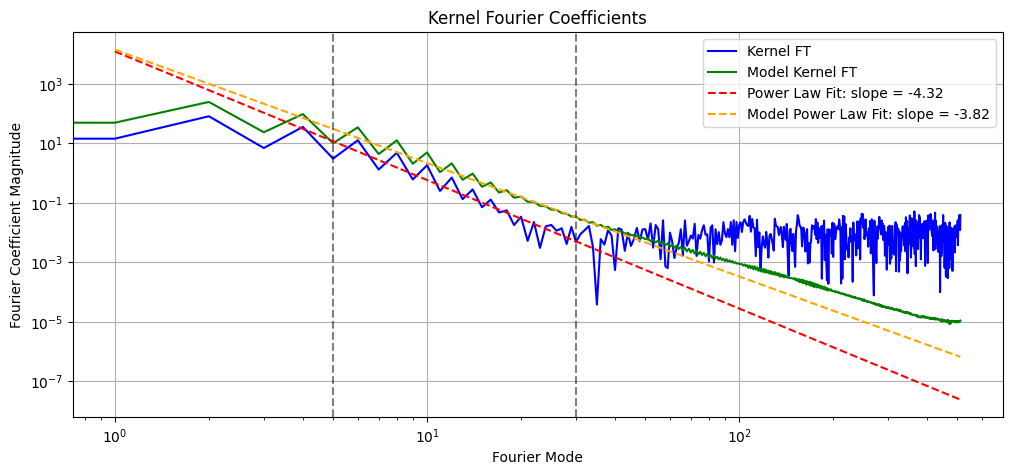

In [ ]:
plt.figure(figsize=(12, 5))
K_ft = np.fft.fftshift(np.fft.fft(K_shifted))
K_model_ft = np.fft.fftshift(np.fft.fft(K_model_shifted))
n_k = len(K_ft)
# fit line to log-log data
x_min, x_max = 5, 30
theta = np.arange(n_k // 2).astype(float)
mask = (theta >= x_min) & (theta <= x_max)
K_ft_mag = np.abs(K_ft[n_k // 2:])
p = np.polyfit(np.log10(theta[mask]), np.log10(K_ft_mag[mask]), 1)
q = np.polyfit(np.log10(theta[mask]), np.log10(np.abs(K_model_ft[n_k // 2:][mask])), 1)
plt.plot(theta, K_ft_mag, label='Kernel FT', color='blue')
plt.plot(theta, np.abs(K_model_ft[n_k // 2:]), label='Model Kernel FT', color='green')
plt.plot(theta, 10**(p[1]) * theta**(p[0]), linestyle='dashed', color='red', label=f'Power Law Fit: slope = {p[0]:.2f}')
plt.plot(theta, 10**(q[1]) * theta**(q[0]), linestyle='dashed', color='orange', label=f'Model Power Law Fit: slope = {q[0]:.2f}')
plt.axvline(x_min, color='k', linestyle='--', alpha=0.5)
plt.axvline(x_max, color='k', linestyle='--', alpha=0.5)
plt.grid()
plt.xlabel('Fourier Mode')
plt.ylabel('Fourier Coefficient Magnitude')
plt.xscale('log')
plt.yscale('log')
plt.title('Kernel Fourier Coefficients')
plt.legend()